In [0]:
#Calculating overall sales KPIs

In [0]:
from pyspark.sql import functions as F

fact_sales = spark.table(
    "workspace.indian_ecommerce_sales_analytics.fact_sales"
)

print("Fact Sales Records:", fact_sales.count())

Fact Sales Records: 250000


In [0]:
gold_total_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .agg(
        F.sum("Realized_Revenue").alias("Total_Gross_Revenue"),
        F.sum("Quantity").alias("Total_Units_Sold"),
        F.countDistinct("Order_ID").alias("Total_Delivered_Orders")
    )
    .withColumn(
        "Average_Order_Value",
        F.round(
            F.col("Total_Gross_Revenue") /
            F.col("Total_Delivered_Orders"),
            2
        )
    )
)
display(gold_total_sales)

Total_Gross_Revenue,Total_Units_Sold,Total_Delivered_Orders,Average_Order_Value
4.741566354410673E9,249834,200139,23691.37


In [0]:
gold_total_sales.select(
    "Total_Gross_Revenue",
    "Total_Delivered_Orders",
    "Average_Order_Value"
).show()

+-------------------+----------------------+-------------------+
|Total_Gross_Revenue|Total_Delivered_Orders|Average_Order_Value|
+-------------------+----------------------+-------------------+
|4.741566354410673E9|                200139|           23691.37|
+-------------------+----------------------+-------------------+



In [0]:
(
    gold_total_sales.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_total_sales"
    )
)

In [0]:
%sql
--1.(Total Sales): What is the total gross revenue, total number of units sold, and average order value (AOV) across the entire platform?
SELECT *
FROM workspace.indian_ecommerce_sales_analytics.gold_total_sales;

Total_Gross_Revenue,Total_Units_Sold,Total_Delivered_Orders,Average_Order_Value
4.741566354409982E9,249834,200139,23691.37


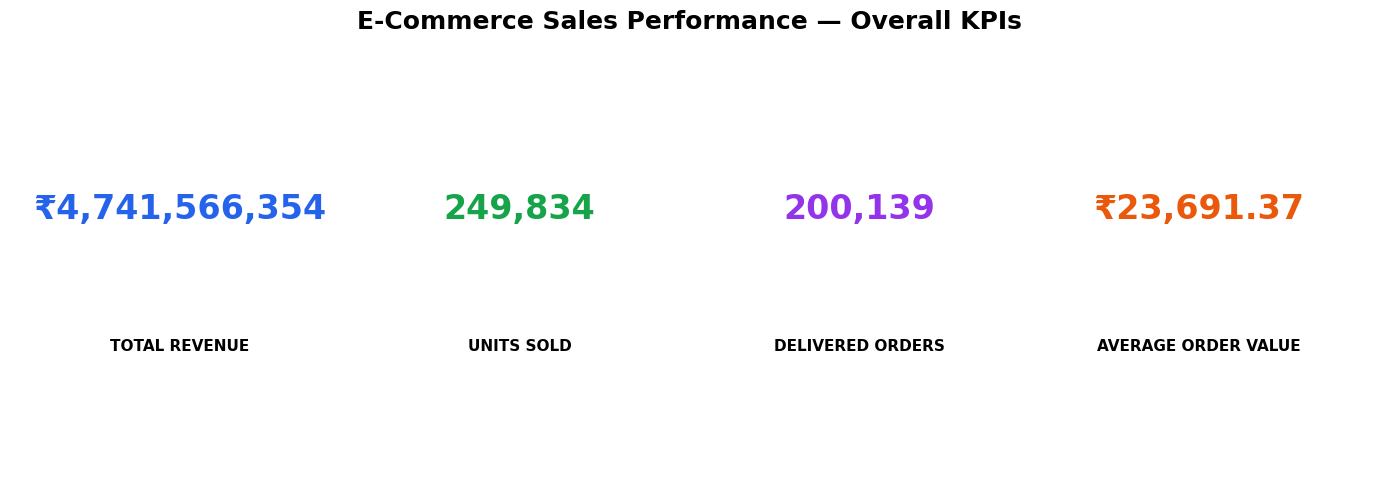

In [0]:
# ============================================================
# Q1 - Visualization 1
# Total Sales KPI Dashboard
# ============================================================

import matplotlib.pyplot as plt

# Convert single-row Spark DataFrame to Pandas
kpi = gold_total_sales.toPandas().iloc[0]

revenue = kpi["Total_Gross_Revenue"]
units = kpi["Total_Units_Sold"]
orders = kpi["Total_Delivered_Orders"]
aov = kpi["Average_Order_Value"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.axis("off")

# KPI positions
kpis = [
    ("TOTAL REVENUE", f"₹{revenue:,.0f}"),
    ("UNITS SOLD", f"{units:,.0f}"),
    ("DELIVERED ORDERS", f"{orders:,.0f}"),
    ("AVERAGE ORDER VALUE", f"₹{aov:,.2f}")
]

positions = [0.125, 0.375, 0.625, 0.875]

colors = ["#2563EB", "#16A34A", "#9333EA", "#EA580C"]

for (title, value), x, color in zip(kpis, positions, colors):

    ax.text(
        x, 0.65,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color=color
    )

    ax.text(
        x, 0.32,
        title,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "E-Commerce Sales Performance — Overall KPIs",
    fontsize=18,
    fontweight="bold",
    pad=25
)

plt.tight_layout()
plt.show()

In [0]:
#2.(Monthly Revenue): What is the exact breakdown of gross revenue generated month-over-month?
from pyspark.sql import functions as F
from pyspark.sql.window import Window

monthly_revenue = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy(
        "Year",
        "Month",
        "Month_Name",
        "Year_Month"
    )
    .agg(
        F.sum("Realized_Revenue").alias("Gross_Revenue"),
        F.sum("Quantity").alias("Units_Sold"),
        F.countDistinct("Order_ID").alias("Delivered_Orders")
    )
)

monthly_revenue = monthly_revenue.withColumn(
    "AOV",
    F.round(
        F.col("Gross_Revenue") /
        F.col("Delivered_Orders"),
        2
    )
)

In [0]:
month_window = Window.orderBy("Year", "Month")
monthly_revenue = monthly_revenue.withColumn(
    "Previous_Month_Revenue",
    F.lag("Gross_Revenue").over(month_window)
)

monthly_revenue = monthly_revenue.withColumn(
    "MoM_Growth_Percent",
    F.round(
        (
            (
                F.col("Gross_Revenue") -
                F.col("Previous_Month_Revenue")
            )
            /
            F.col("Previous_Month_Revenue")
        ) * 100,
        2
    )
)



In [0]:
gold_monthly_revenue = (
    monthly_revenue
    .select(
        "Year",
        "Month",
        "Month_Name",
        "Year_Month",
        "Gross_Revenue",
        "Units_Sold",
        "Delivered_Orders",
        "AOV",
        "Previous_Month_Revenue",
        "MoM_Growth_Percent"
    )
    .orderBy("Year", "Month")
)
display(gold_monthly_revenue)

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent
2024,6,June,2024-06,1.908291859699998E8,9936,7962,23967.49,null,null
2024,7,July,2024-07,1.9138672549000004E8,10147,8107,23607.59,1.908291859699998E8,0.29
2024,8,August,2024-08,1.900992564700002E8,10068,8088,23503.86,1.9138672549000004E8,-0.67
2024,9,September,2024-09,1.8196487165000075E8,9600,7725,23555.32,1.900992564700002E8,-4.28
2024,10,October,2024-10,1.8921689947000098E8,10094,7985,23696.54,1.8196487165000075E8,3.99
2024,11,November,2024-11,1.8763252436000043E8,9901,7882,23805.19,1.8921689947000098E8,-0.84
2024,12,December,2024-12,1.9291251777000034E8,10142,8103,23807.54,1.8763252436000043E8,2.81
2025,1,January,2025-01,1.9471134962999994E8,10326,8216,23699.04,1.9291251777000034E8,0.93
2025,2,February,2025-02,1.7212738141000047E8,9147,7378,23329.82,1.9471134962999994E8,-11.6
2025,3,March,2025-03,1.9461048798000008E8,10212,8242,23612.05,1.7212738141000047E8,13.06


In [0]:
#finding the highest revenue month
display(
    gold_monthly_revenue
    .orderBy(F.desc("Gross_Revenue"))
    .limit(5)
)

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent
2026,3,March,2026-03,1.9905544030999938E8,10301,8195,24289.86,1.826451176400007E8,8.98
2025,12,December,2025-12,1.9669215494000003E8,10267,8217,23937.22,1.827592908199999E8,7.62
2025,10,October,2025-10,1.9619296931999883E8,10345,8297,23646.25,1.8495307245000038E8,6.08
2025,8,August,2025-08,1.9488571441000018E8,10187,8171,23850.9,1.924507375999997E8,1.27
2025,1,January,2025-01,1.9471134962999994E8,10326,8216,23699.04,1.9291251777000034E8,0.93


In [0]:
#Finding the highest MoM growth
display(
    gold_monthly_revenue
    .filter(F.col("MoM_Growth_Percent").isNotNull())
    .orderBy(F.desc("MoM_Growth_Percent"))
    .limit(5)
)

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent
2025,3,March,2025-03,1.9461048798000008E8,10212,8242,23612.05,1.7212738141000047E8,13.06
2026,3,March,2026-03,1.9905544030999938E8,10301,8195,24289.86,1.826451176400007E8,8.98
2025,12,December,2025-12,1.9669215494000003E8,10267,8217,23937.22,1.827592908199999E8,7.62
2025,10,October,2025-10,1.9619296931999883E8,10345,8297,23646.25,1.8495307245000038E8,6.08
2024,10,October,2024-10,1.8921689947000098E8,10094,7985,23696.54,1.8196487165000075E8,3.99


In [0]:
display(
    gold_monthly_revenue
    .filter(F.col("MoM_Growth_Percent").isNotNull())
    .orderBy(F.asc("MoM_Growth_Percent"))
    .limit(5)
)

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent
2025,2,February,2025-02,1.7212738141000047E8,9147,7378,23329.82,1.9471134962999994E8,-11.6
2025,11,November,2025-11,1.827592908199999E8,9870,7910,23104.84,1.9619296931999883E8,-6.85
2026,4,April,2026-04,1.8562797457999963E8,9762,7845,23661.95,1.9905544030999938E8,-6.75
2025,9,September,2025-09,1.8495307245000038E8,9902,7972,23200.34,1.9488571441000018E8,-5.1
2025,6,June,2025-06,1.8558648977999982E8,9912,7903,23483.04,1.9445358323000053E8,-4.56


In [0]:
(
    gold_monthly_revenue.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_monthly_revenue"
    )
)

In [0]:
%sql
SELECT *
FROM workspace.indian_ecommerce_sales_analytics.gold_monthly_revenue
ORDER BY Year, Month;

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent
2024,6,June,2024-06,1.9082918597000024E8,9936,7962,23967.49,null,null
2024,7,July,2024-07,1.9138672549000022E8,10147,8107,23607.59,1.9082918597000024E8,0.29
2024,8,August,2024-08,1.9009925647000003E8,10068,8088,23503.86,1.9138672549000022E8,-0.67
2024,9,September,2024-09,1.8196487165000015E8,9600,7725,23555.32,1.9009925647000003E8,-4.28
2024,10,October,2024-10,1.8921689947000045E8,10094,7985,23696.54,1.8196487165000015E8,3.99
2024,11,November,2024-11,1.8763252436000016E8,9901,7882,23805.19,1.8921689947000045E8,-0.84
2024,12,December,2024-12,1.9291251777000028E8,10142,8103,23807.54,1.8763252436000016E8,2.81
2025,1,January,2025-01,1.947113496300003E8,10326,8216,23699.04,1.9291251777000028E8,0.93
2025,2,February,2025-02,1.7212738141000018E8,9147,7378,23329.82,1.947113496300003E8,-11.6
2025,3,March,2025-03,1.9461048798000044E8,10212,8242,23612.05,1.7212738141000018E8,13.06


In [0]:
month_window = Window.orderBy("Year_Month")

In [0]:
gold_monthly_revenue = monthly_revenue.withColumn(
    "Previous_Month_Revenue",
    F.lag("Gross_Revenue").over(month_window)
)
gold_monthly_revenue = gold_monthly_revenue.withColumn(
    "MoM_Growth_Percent",
    F.round(
        (
            (
                F.col("Gross_Revenue") -
                F.col("Previous_Month_Revenue")
            )
            / F.col("Previous_Month_Revenue")
        ) * 100,
        2
    )
)
#2. (Monthly Revenue): What is the exact breakdown of gross revenue generated month-over-month?
display(
    gold_monthly_revenue
    .orderBy("Year", "Month")
)

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent
2024,6,June,2024-06,1.908291859699998E8,9936,7962,23967.49,null,null
2024,7,July,2024-07,1.9138672549000004E8,10147,8107,23607.59,1.908291859699998E8,0.29
2024,8,August,2024-08,1.900992564700002E8,10068,8088,23503.86,1.9138672549000004E8,-0.67
2024,9,September,2024-09,1.8196487165000075E8,9600,7725,23555.32,1.900992564700002E8,-4.28
2024,10,October,2024-10,1.8921689947000098E8,10094,7985,23696.54,1.8196487165000075E8,3.99
2024,11,November,2024-11,1.8763252436000043E8,9901,7882,23805.19,1.8921689947000098E8,-0.84
2024,12,December,2024-12,1.9291251777000034E8,10142,8103,23807.54,1.8763252436000043E8,2.81
2025,1,January,2025-01,1.9471134962999994E8,10326,8216,23699.04,1.9291251777000034E8,0.93
2025,2,February,2025-02,1.7212738141000047E8,9147,7378,23329.82,1.9471134962999994E8,-11.6
2025,3,March,2025-03,1.9461048798000008E8,10212,8242,23612.05,1.7212738141000047E8,13.06


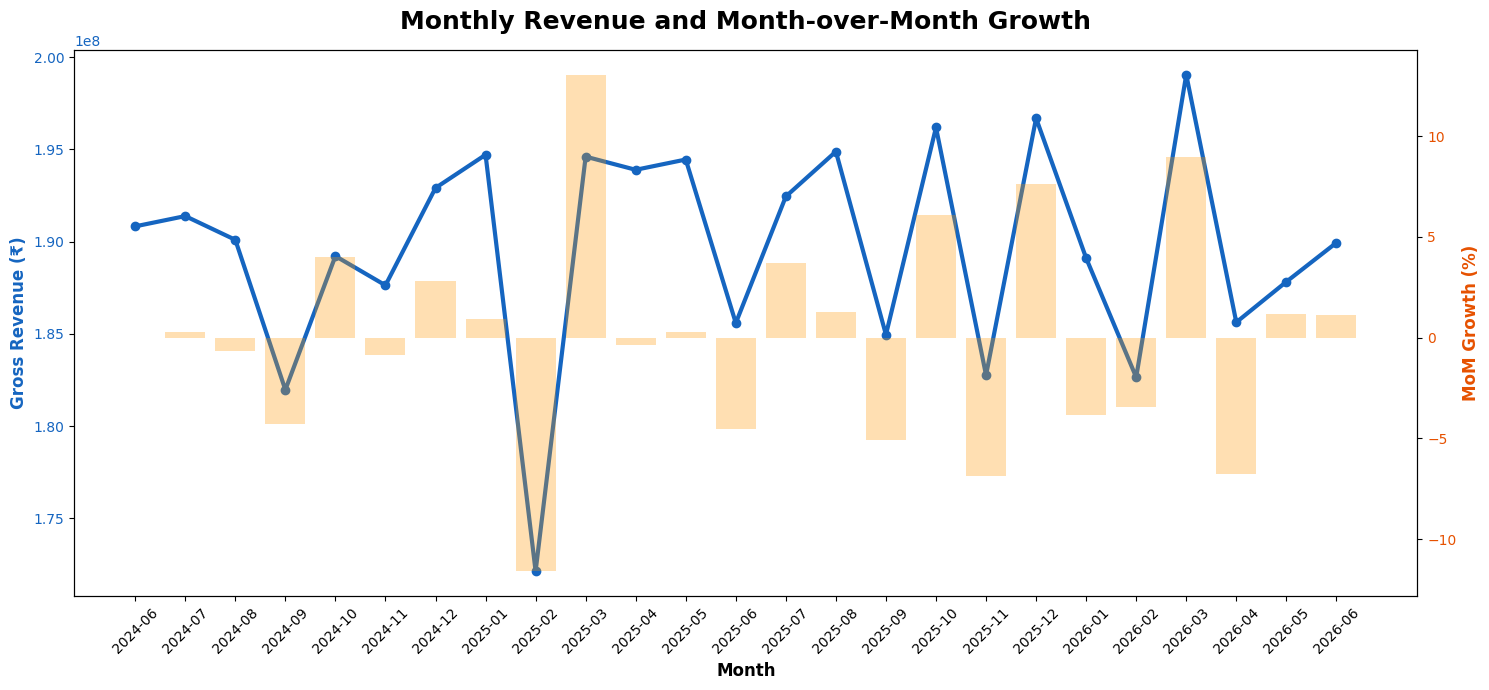

In [0]:
# ============================================================
# Q2 Visualization — Monthly Revenue & MoM Growth
# ============================================================

import matplotlib.pyplot as plt

pdf = (
    gold_monthly_revenue
    .orderBy("Year", "Month")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(15, 7))

# Revenue line
ax1.plot(
    pdf["Year_Month"],
    pdf["Gross_Revenue"],
    marker="o",
    linewidth=3,
    markersize=6,
    color="#1565C0",
    label="Monthly Revenue"
)

ax1.set_xlabel(
    "Month",
    fontsize=12,
    fontweight="bold"
)

ax1.set_ylabel(
    "Gross Revenue (₹)",
    fontsize=12,
    fontweight="bold",
    color="#1565C0"
)

ax1.tick_params(
    axis="y",
    labelcolor="#1565C0"
)

ax1.tick_params(
    axis="x",
    rotation=45
)

# MoM growth on second axis
ax2 = ax1.twinx()

ax2.bar(
    pdf["Year_Month"],
    pdf["MoM_Growth_Percent"],
    alpha=0.30,
    color="#FF9800",
    label="MoM Growth %"
)

ax2.set_ylabel(
    "MoM Growth (%)",
    fontsize=12,
    fontweight="bold",
    color="#E65100"
)

ax2.tick_params(
    axis="y",
    labelcolor="#E65100"
)

plt.title(
    "Monthly Revenue and Month-over-Month Growth",
    fontsize=18,
    fontweight="bold",
    pad=15
)

fig.tight_layout()
plt.show()

In [0]:
#3. (Revenue Trend): Does our revenue timeline show predictable seasonal trends, or did specific quarters experience sharp, anomalous dips or spikes?(e.g., Diwali, Big Billion Days)
quarterly_revenue = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy(
        "Year",
        "Quarter"
    )
    .agg(
        F.sum("Realized_Revenue").alias("Quarterly_Revenue"),
        F.sum("Quantity").alias("Units_Sold"),
        F.countDistinct("Order_ID").alias("Delivered_Orders")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Quarterly_Revenue") /
            F.col("Delivered_Orders"),
            2
        )
    )
    .orderBy("Year", "Quarter")
)
display(quarterly_revenue)

Year,Quarter,Quarterly_Revenue,Units_Sold,Delivered_Orders,AOV
2024,2,1.908291859699998E8,9936,7962,23967.49
2024,3,5.634508536099944E8,29815,23920,23555.64
2024,4,5.697619415999945E8,30137,23970,23769.79
2025,1,5.614492190199897E8,29685,23836,23554.67
2025,2,5.739361964599901E8,30060,24095,23819.72
2025,3,5.722895244599963E8,30290,24299,23551.98
2025,4,5.756444150799936E8,30482,24424,23568.8
2026,1,5.708091400699972E8,29763,23796,23987.61
2026,2,5.633958781399907E8,29666,23837,23635.35


In [0]:
#Finding Best and Worst Quarters
display(
    quarterly_revenue
    .orderBy(F.desc("Quarterly_Revenue"))
    .limit(5)
)

Year,Quarter,Quarterly_Revenue,Units_Sold,Delivered_Orders,AOV
2025,4,5.756444150799936E8,30482,24424,23568.8
2025,2,5.739361964599901E8,30060,24095,23819.72
2025,3,5.722895244599963E8,30290,24299,23551.98
2026,1,5.708091400699972E8,29763,23796,23987.61
2024,4,5.697619415999945E8,30137,23970,23769.79


In [0]:
#lowest revenue quaters
display(
    quarterly_revenue
    .orderBy(F.asc("Quarterly_Revenue"))
    .limit(5)
)

Year,Quarter,Quarterly_Revenue,Units_Sold,Delivered_Orders,AOV
2024,2,1.908291859699998E8,9936,7962,23967.49
2025,1,5.614492190199897E8,29685,23836,23554.67
2026,2,5.633958781399907E8,29666,23837,23635.35
2024,3,5.634508536099944E8,29815,23920,23555.64
2024,4,5.697619415999945E8,30137,23970,23769.79


In [0]:
#Quarterly MoM-style Growth
quarter_window = Window.orderBy(
    "Year",
    "Quarter"
)

quarterly_revenue = quarterly_revenue.withColumn(
    "Previous_Quarter_Revenue",
    F.lag("Quarterly_Revenue").over(quarter_window)
)
quarterly_revenue = quarterly_revenue.withColumn(
    "QoQ_Growth_Percent",
    F.round(
        (
            (
                F.col("Quarterly_Revenue") -
                F.col("Previous_Quarter_Revenue")
            )
            / F.col("Previous_Quarter_Revenue")
        ) * 100,
        2
    )
)
display(
    quarterly_revenue.orderBy("Year", "Quarter")
)

Year,Quarter,Quarterly_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Quarter_Revenue,QoQ_Growth_Percent
2024,2,1.908291859699998E8,9936,7962,23967.49,null,null
2024,3,5.634508536099944E8,29815,23920,23555.64,1.908291859699998E8,195.26
2024,4,5.697619415999945E8,30137,23970,23769.79,5.634508536099944E8,1.12
2025,1,5.614492190199897E8,29685,23836,23554.67,5.697619415999945E8,-1.46
2025,2,5.739361964599901E8,30060,24095,23819.72,5.614492190199897E8,2.22
2025,3,5.722895244599963E8,30290,24299,23551.98,5.739361964599901E8,-0.29
2025,4,5.756444150799936E8,30482,24424,23568.8,5.722895244599963E8,0.59
2026,1,5.708091400699972E8,29763,23796,23987.61,5.756444150799936E8,-0.84
2026,2,5.633958781399907E8,29666,23837,23635.35,5.708091400699972E8,-1.3


In [0]:
#Detect Revenue anamaly
revenue_stats = (
    gold_monthly_revenue
    .agg(
        F.avg("Gross_Revenue").alias("Average_Revenue"),
        F.stddev("Gross_Revenue").alias("Revenue_StdDev")
    )
)
display(revenue_stats)

Average_Revenue,Revenue_StdDev
1.896626541764001E8,5944418.819472372


In [0]:
#statistics and flag anamalies
gold_revenue_trend = (
    gold_monthly_revenue
    .crossJoin(revenue_stats)
    .withColumn(
        "Revenue_Z_Score",
        F.round(
            (
                F.col("Gross_Revenue") -
                F.col("Average_Revenue")
            ) /
            F.col("Revenue_StdDev"),
            2
        )
    )
    .withColumn(
        "Revenue_Anomaly",
        F.when(
            F.abs(F.col("Revenue_Z_Score")) >= 2,
            "Anomaly"
        ).otherwise("Normal")
    )
)

display(
    gold_revenue_trend
    .filter(F.col("Revenue_Anomaly") == "Anomaly")
    .select(
        "Year",
        "Month",
        "Month_Name",
        "Year_Month",
        "Gross_Revenue",
        "MoM_Growth_Percent",
        "Revenue_Z_Score",
        "Revenue_Anomaly"
    )
    .orderBy("Year", "Month")
)

Year,Month,Month_Name,Year_Month,Gross_Revenue,MoM_Growth_Percent,Revenue_Z_Score,Revenue_Anomaly
2025,2,February,2025-02,1.7212738141000047E8,-11.6,-2.95,Anomaly


In [0]:
#monthly seasonality
seasonality = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("Month", "Month_Name")
    .agg(
        F.sum("Realized_Revenue").alias("Total_Revenue"),
        F.sum("Quantity").alias("Total_Units"),
        F.countDistinct("Order_ID").alias("Total_Orders")
    )
    .withColumn(
        "Average_Order_Value",
        F.round(
            F.col("Total_Revenue") /
            F.col("Total_Orders"),
            2
        )
    )
    .orderBy("Month")
)
display(seasonality)

Month,Month_Name,Total_Revenue,Total_Units,Total_Orders,Average_Order_Value
1,January,3.838199317499984E8,20456,16340,23489.59
2,February,3.547724990499953E8,18479,14855,23882.36
3,March,3.93665928289998E8,20513,16437,23949.99
4,April,3.795240980299972E8,19719,15824,23984.08
5,May,3.8227902591999704E8,20214,16244,23533.55
6,June,5.663581366199888E8,29729,23826,23770.59
7,July,3.838374630899982E8,20348,16263,23601.89
8,August,3.849849708799961E8,20255,16259,23678.27
9,September,3.669179440999984E8,19502,15697,23375.04
10,October,3.8540986878999794E8,20439,16282,23670.92


In [0]:
#Identify Strongest Calendar Months and weekest
display(
    seasonality
    .orderBy(F.desc("Total_Revenue"))
    .limit(5)
)
display(
    seasonality
    .orderBy(F.asc("Total_Revenue"))
    .limit(5)
)

Month,Month_Name,Total_Revenue,Total_Units,Total_Orders,Average_Order_Value
6,June,5.663581366199888E8,29729,23826,23770.59
3,March,3.93665928289998E8,20513,16437,23949.99
12,December,3.896046727099971E8,20409,16320,23872.84
10,October,3.8540986878999794E8,20439,16282,23670.92
8,August,3.849849708799961E8,20255,16259,23678.27


Month,Month_Name,Total_Revenue,Total_Units,Total_Orders,Average_Order_Value
2,February,3.547724990499953E8,18479,14855,23882.36
9,September,3.669179440999984E8,19502,15697,23375.04
11,November,3.7039181517999685E8,19771,15792,23454.4
4,April,3.795240980299972E8,19719,15824,23984.08
5,May,3.8227902591999704E8,20214,16244,23533.55


In [0]:
#Saving  the Main Gold Trend Table
gold_revenue_trend = gold_revenue_trend.select(
    "Year",
    "Month",
    "Month_Name",
    "Year_Month",
    "Gross_Revenue",
    "Units_Sold",
    "Delivered_Orders",
    "AOV",
    "Previous_Month_Revenue",
    "MoM_Growth_Percent",
    "Average_Revenue",
    "Revenue_StdDev",
    "Revenue_Z_Score",
    "Revenue_Anomaly"
)
(
    gold_revenue_trend.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_revenue_trend"
    )
)

In [0]:
%sql
SELECT *
FROM workspace.indian_ecommerce_sales_analytics.gold_revenue_trend
ORDER BY Year, Month;

Year,Month,Month_Name,Year_Month,Gross_Revenue,Units_Sold,Delivered_Orders,AOV,Previous_Month_Revenue,MoM_Growth_Percent,Average_Revenue,Revenue_StdDev,Revenue_Z_Score,Revenue_Anomaly
2024,6,June,2024-06,1.9082918597000045E8,9936,7962,23967.49,null,null,1.896626541764001E8,5944418.8194723725,0.2,Normal
2024,7,July,2024-07,1.9138672549000022E8,10147,8107,23607.59,1.9082918597000045E8,0.29,1.896626541764001E8,5944418.8194723725,0.29,Normal
2024,8,August,2024-08,1.9009925647000006E8,10068,8088,23503.86,1.9138672549000022E8,-0.67,1.896626541764001E8,5944418.8194723725,0.07,Normal
2024,9,September,2024-09,1.8196487165000004E8,9600,7725,23555.32,1.9009925647000006E8,-4.28,1.896626541764001E8,5944418.8194723725,-1.29,Normal
2024,10,October,2024-10,1.8921689947000018E8,10094,7985,23696.54,1.8196487165000004E8,3.99,1.896626541764001E8,5944418.8194723725,-0.07,Normal
2024,11,November,2024-11,1.876325243600003E8,9901,7882,23805.19,1.8921689947000018E8,-0.84,1.896626541764001E8,5944418.8194723725,-0.34,Normal
2024,12,December,2024-12,1.9291251777000034E8,10142,8103,23807.54,1.876325243600003E8,2.81,1.896626541764001E8,5944418.8194723725,0.55,Normal
2025,1,January,2025-01,1.947113496300005E8,10326,8216,23699.04,1.9291251777000034E8,0.93,1.896626541764001E8,5944418.8194723725,0.85,Normal
2025,2,February,2025-02,1.7212738141000015E8,9147,7378,23329.82,1.947113496300005E8,-11.6,1.896626541764001E8,5944418.8194723725,-2.95,Anomaly
2025,3,March,2025-03,1.9461048798000005E8,10212,8242,23612.05,1.7212738141000015E8,13.06,1.896626541764001E8,5944418.8194723725,0.83,Normal


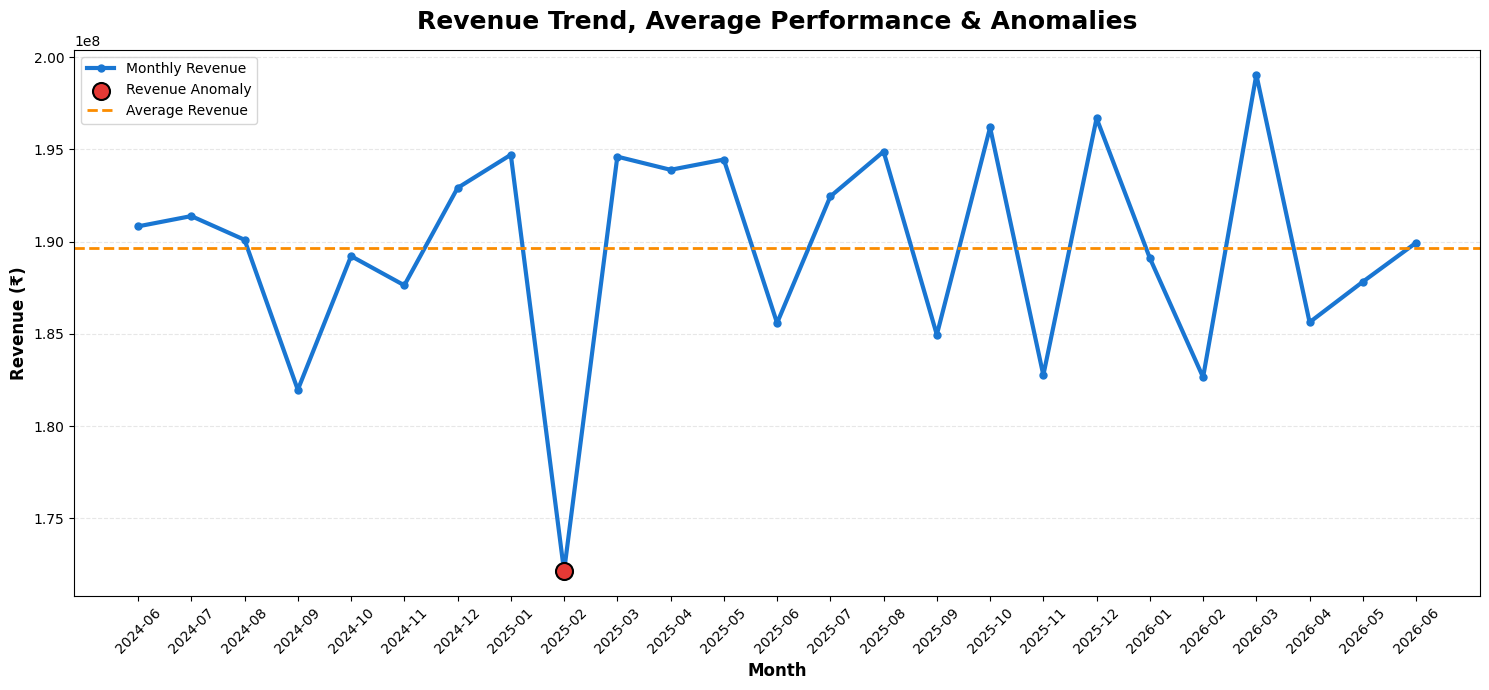

In [0]:
# ============================================================
# Q3 Visualization — Revenue Trend & Anomalies
# ============================================================

import matplotlib.pyplot as plt

pdf = (
    gold_revenue_trend
    .orderBy("Year", "Month")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(15, 7))

# Main revenue trend
ax.plot(
    pdf["Year_Month"],
    pdf["Gross_Revenue"],
    marker="o",
    linewidth=3,
    markersize=5,
    color="#1976D2",
    label="Monthly Revenue"
)

# Highlight anomalies
anomalies = pdf[
    pdf["Revenue_Anomaly"] == "Anomaly"
]

ax.scatter(
    anomalies["Year_Month"],
    anomalies["Gross_Revenue"],
    s=150,
    color="#E53935",
    edgecolors="black",
    linewidths=1.5,
    zorder=5,
    label="Revenue Anomaly"
)

# Average revenue line
average_revenue = pdf["Average_Revenue"].iloc[0]

ax.axhline(
    average_revenue,
    linestyle="--",
    linewidth=2,
    color="#FB8C00",
    label="Average Revenue"
)

ax.set_xlabel(
    "Month",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Revenue (₹)",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Revenue Trend, Average Performance & Anomalies",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [0]:
#(Order Status Analysis): What percentage of total orders result in successful deliveries versus cancellations or returns, and does this failure rate spike during specific months?
from pyspark.sql import functions as F
from pyspark.sql.window import Window

fact_sales = spark.table(
    "workspace.indian_ecommerce_sales_analytics.fact_sales"
)

print("Total Sales Records:", fact_sales.count())

Total Sales Records: 250000


In [0]:
order_status = (
    fact_sales
    .groupBy("Order_Status")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Total_Amount").alias("Total_Amount")
    )
    .withColumn(
        "Order_Percentage",
        F.round(
            F.col("Total_Orders") /
            F.sum("Total_Orders").over(Window.partitionBy()) * 100,
            2
        )
    )
    .orderBy(F.desc("Total_Orders"))
)

display(order_status)

Order_Status,Total_Orders,Total_Amount,Order_Percentage
Delivered,200139,4.741566354410673E9,80.06
Cancelled,12507,3.021405218099997E8,5.0
Returned,12493,3.0040473645999825E8,5.0
Shipped,12459,2.9112083049000096E8,4.98
Processing,12402,2.954608111299993E8,4.96


In [0]:
#Calculate Failure Rate
order_status_summary = (
    fact_sales
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),

        F.countDistinct(
            F.when(
                F.col("Order_Status") == "Delivered",
                F.col("Order_ID")
            )
        ).alias("Delivered_Orders"),

        F.countDistinct(
            F.when(
                F.col("Order_Status").isin(
                    "Cancelled",
                    "Returned"
                ),
                F.col("Order_ID")
            )
        ).alias("Failed_Orders")
    )
)
order_status_summary = order_status_summary.withColumn(
    "Failure_Rate_Percent",
    F.round(
        F.col("Failed_Orders") /
        F.col("Total_Orders") * 100,
        2
    )
)
display(order_status_summary)

Total_Orders,Delivered_Orders,Failed_Orders,Failure_Rate_Percent
250000,200139,25000,10.0


In [0]:
#Monthly Failure Rate
monthly_failure = (
    fact_sales
    .groupBy(
        "Year",
        "Month",
        "Year_Month"
    )
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),

        F.countDistinct(
            F.when(
                F.col("Order_Status").isin(
                    "Cancelled",
                    "Returned"
                ),
                F.col("Order_ID")
            )
        ).alias("Failed_Orders"),

        F.countDistinct(
            F.when(
                F.col("Order_Status") == "Delivered",
                F.col("Order_ID")
            )
        ).alias("Delivered_Orders")
    )
    .withColumn(
        "Failure_Rate_Percent",
        F.round(
            F.col("Failed_Orders") /
            F.col("Total_Orders") * 100,
            2
        )
    )
    .orderBy("Year", "Month")
)

display(monthly_failure)



Year,Month,Year_Month,Total_Orders,Failed_Orders,Delivered_Orders,Failure_Rate_Percent
2024,6,2024-06,10008,1041,7962,10.4
2024,7,2024-07,10216,1050,8107,10.28
2024,8,2024-08,10158,1066,8088,10.49
2024,9,2024-09,9704,940,7725,9.69
2024,10,2024-10,10034,1049,7985,10.45
2024,11,2024-11,9865,1040,7882,10.54
2024,12,2024-12,10156,1032,8103,10.16
2025,1,2025-01,10243,1007,8216,9.83
2025,2,2025-02,9211,929,7378,10.09
2025,3,2025-03,10296,1014,8242,9.85


In [0]:
display(
    monthly_failure
    .orderBy(F.desc("Failure_Rate_Percent"))
    .limit(10)
)

Year,Month,Year_Month,Total_Orders,Failed_Orders,Delivered_Orders,Failure_Rate_Percent
2024,11,2024-11,9865,1040,7882,10.54
2026,6,2026-06,9908,1043,7961,10.53
2024,8,2024-08,10158,1066,8088,10.49
2024,10,2024-10,10034,1049,7985,10.45
2026,5,2026-05,10031,1045,8031,10.42
2024,6,2024-06,10008,1041,7962,10.4
2024,7,2024-07,10216,1050,8107,10.28
2025,6,2025-06,9919,1016,7903,10.24
2024,12,2024-12,10156,1032,8103,10.16
2026,4,2026-04,9801,992,7845,10.12


In [0]:
#creating final gold table
gold_order_status = monthly_failure.select(
    "Year",
    "Month",
    "Year_Month",
    "Total_Orders",
    "Delivered_Orders",
    "Failed_Orders",
    "Failure_Rate_Percent"
)

(
    gold_order_status.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_order_status"
    )
)

In [0]:
%sql
SELECT *
FROM workspace.indian_ecommerce_sales_analytics.gold_order_status
ORDER BY Year, Month;

Year,Month,Year_Month,Total_Orders,Delivered_Orders,Failed_Orders,Failure_Rate_Percent
2024,6,2024-06,10008,7962,1041,10.4
2024,7,2024-07,10216,8107,1050,10.28
2024,8,2024-08,10158,8088,1066,10.49
2024,9,2024-09,9704,7725,940,9.69
2024,10,2024-10,10034,7985,1049,10.45
2024,11,2024-11,9865,7882,1040,10.54
2024,12,2024-12,10156,8103,1032,10.16
2025,1,2025-01,10243,8216,1007,9.83
2025,2,2025-02,9211,7378,929,10.09
2025,3,2025-03,10296,8242,1014,9.85


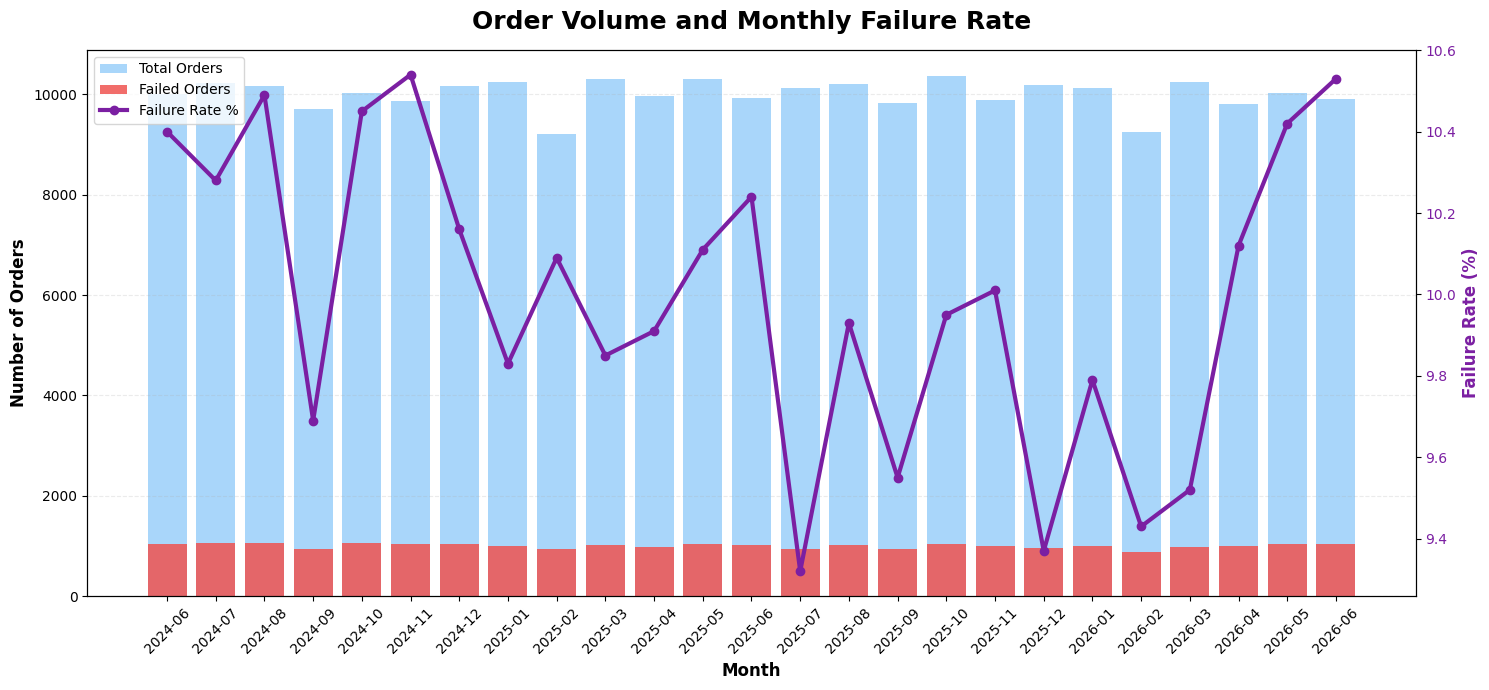

In [0]:
# ============================================================
# Q04 Visualization — Order Volume & Failure Rate
# ============================================================

import matplotlib.pyplot as plt

pdf = (
    gold_order_status
    .orderBy("Year", "Month")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(15, 7))

# Total orders
ax1.bar(
    pdf["Year_Month"],
    pdf["Total_Orders"],
    alpha=0.45,
    color="#42A5F5",
    label="Total Orders"
)

# Failed orders
ax1.bar(
    pdf["Year_Month"],
    pdf["Failed_Orders"],
    alpha=0.85,
    color="#EF5350",
    label="Failed Orders"
)

ax1.set_xlabel(
    "Month",
    fontsize=12,
    fontweight="bold"
)

ax1.set_ylabel(
    "Number of Orders",
    fontsize=12,
    fontweight="bold"
)

ax1.tick_params(
    axis="x",
    rotation=45
)

# Failure rate
ax2 = ax1.twinx()

ax2.plot(
    pdf["Year_Month"],
    pdf["Failure_Rate_Percent"],
    marker="o",
    linewidth=3,
    markersize=6,
    color="#7B1FA2",
    label="Failure Rate %"
)

ax2.set_ylabel(
    "Failure Rate (%)",
    fontsize=12,
    fontweight="bold",
    color="#7B1FA2"
)

ax2.tick_params(
    axis="y",
    labelcolor="#7B1FA2"
)

plt.title(
    "Order Volume and Monthly Failure Rate",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [0]:
# Q6.(Payment Method Analysis): What is the distribution of sales across different payment modes (UPI, Net Banking, Credit/Debit Cards, Cash on Delivery), and which channel drives the highest transaction amounts?

# Q06 - State-wise Sales Analysis

from pyspark.sql import functions as F
from pyspark.sql.window import Window

state_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("State")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") / F.col("Total_Orders"),
            2
        )
    )
)

# Total revenue across all states
total_revenue = (
    state_sales
    .agg(F.sum("Gross_Revenue").alias("Total_Revenue"))
    .collect()[0]["Total_Revenue"]
)

# Revenue share
state_sales = (
    state_sales
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") / F.lit(total_revenue) * 100,
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(state_sales)

State,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
UP,26134,32609,6.187058702599883E8,23674.37,13.05
Rajasthan,25440,31803,6.047445652499909E8,23771.41,12.75
Haryana,25656,32037,5.977206672799925E8,23297.5,12.61
Maharashtra,20364,25434,4.8476088661999536E8,23804.8,10.22
Punjab,20240,25235,4.768407786899954E8,23559.33,10.06
Gujarat,20141,25116,4.7601592036999625E8,23634.18,10.04
Delhi,15614,19443,3.816592395999999E8,24443.4,8.05
Tamil Nadu,15804,19804,3.759771005399966E8,23790.0,7.93
West Bengal,15514,19403,3.647380367999948E8,23510.25,7.69
Karnataka,15232,18950,3.604032889999999E8,23660.93,7.6


In [0]:
# Calculate cumulative revenue share

window_spec = (
    Window
    .orderBy(F.desc("Gross_Revenue"))
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

state_sales_ranked = (
    state_sales
    .withColumn(
        "Cumulative_Revenue_Share_Percent",
        F.round(
            F.sum("Revenue_Share_Percent").over(window_spec),
            2
        )
    )
)

display(state_sales_ranked)

State,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent,Cumulative_Revenue_Share_Percent
UP,26134,32609,6.187058702599883E8,23674.37,13.05,13.05
Rajasthan,25440,31803,6.047445652499909E8,23771.41,12.75,25.8
Haryana,25656,32037,5.977206672799925E8,23297.5,12.61,38.41
Maharashtra,20364,25434,4.8476088661999536E8,23804.8,10.22,48.63
Punjab,20240,25235,4.768407786899954E8,23559.33,10.06,58.69
Gujarat,20141,25116,4.7601592036999625E8,23634.18,10.04,68.73
Delhi,15614,19443,3.816592395999999E8,24443.4,8.05,76.78
Tamil Nadu,15804,19804,3.759771005399966E8,23790.0,7.93,84.71
West Bengal,15514,19403,3.647380367999948E8,23510.25,7.69,92.4
Karnataka,15232,18950,3.604032889999999E8,23660.93,7.6,100.0


In [0]:
#top 20% states
top_20_states = (
    state_sales_ranked
    .filter(
        F.col("Cumulative_Revenue_Share_Percent") <= 20
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(top_20_states)

State,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent,Cumulative_Revenue_Share_Percent
UP,26134,32609,6.187058702599883E8,23674.37,13.05,13.05


In [0]:
# Lowest topest states

bottom_states = (
    state_sales
    .orderBy(F.asc("Gross_Revenue"))
    .limit(10)
)

display(bottom_states)

State,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
Karnataka,15232,18950,3.604032889999999E8,23660.93,7.6
West Bengal,15514,19403,3.647380367999948E8,23510.25,7.69
Tamil Nadu,15804,19804,3.759771005399966E8,23790.0,7.93
Delhi,15614,19443,3.816592395999999E8,24443.4,8.05
Gujarat,20141,25116,4.7601592036999625E8,23634.18,10.04
Punjab,20240,25235,4.768407786899954E8,23559.33,10.06
Maharashtra,20364,25434,4.8476088661999536E8,23804.8,10.22
Haryana,25656,32037,5.977206672799925E8,23297.5,12.61
Rajasthan,25440,31803,6.047445652499909E8,23771.41,12.75
UP,26134,32609,6.187058702599883E8,23674.37,13.05


In [0]:
#saving gold table
gold_state_sales = state_sales_ranked

(
    gold_state_sales
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_state_sales"
    )
)

print("gold_state_sales created successfully")

gold_state_sales created successfully


In [0]:
print(
    "Number of states:",
    gold_state_sales.count()
)

Number of states: 10


In [0]:
gold_state_sales.agg(
    F.sum("Gross_Revenue").alias("Total_State_Revenue")
).show()


+-------------------+
|Total_State_Revenue|
+-------------------+
| 4.74156635440995E9|
+-------------------+



In [0]:
gold_state_sales.agg(
    F.sum("Revenue_Share_Percent").alias("Total_Revenue_Share")
).show()

+-------------------+
|Total_Revenue_Share|
+-------------------+
|  99.99999999999997|
+-------------------+



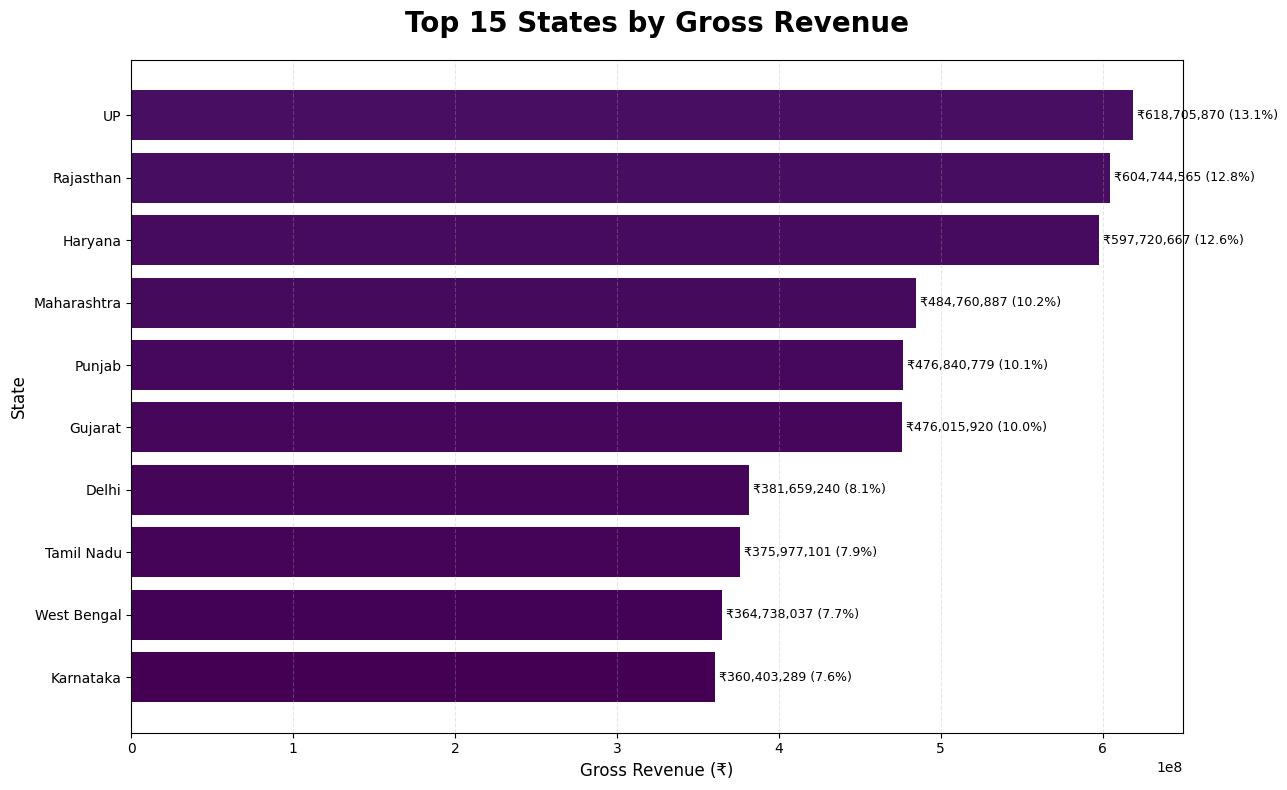

In [0]:
import matplotlib.pyplot as plt

# Convert only the small aggregated state-level dataset to Pandas
pdf = gold_state_sales.toPandas()

# Select top 15 states
top_states_pdf = (
    pdf
    .sort_values("Gross_Revenue", ascending=False)
    .head(15)
    .sort_values("Gross_Revenue", ascending=True)
)

fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(
    top_states_pdf["State"],
    top_states_pdf["Gross_Revenue"],
    color=plt.cm.viridis(
        range(len(top_states_pdf))
    )
)

ax.set_title(
    "Top 15 States by Gross Revenue",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.set_ylabel(
    "State",
    fontsize=12
)

# Add revenue and share labels
for bar, revenue, share in zip(
    bars,
    top_states_pdf["Gross_Revenue"],
    top_states_pdf["Revenue_Share_Percent"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{revenue:,.0f} ({share:.1f}%)",
        va="center",
        fontsize=9
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
#7Q.(City-wise Sales): How does our sales distribution compare between Tier-1, Tier-2, and Tier-3 cities regarding order volumes and average basket sizes?

In [0]:
# Q07 - City-wise Sales Analysis

from pyspark.sql import functions as F

city_tier_df = (
    fact_sales
    .withColumn(
        "City_Tier",
        F.when(
            F.upper(F.trim(F.col("City"))).isin(
                "MUMBAI",
                "DELHI",
                "BANGALORE",
                "BENGALURU",
                "HYDERABAD",
                "CHENNAI",
                "KOLKATA",
                "PUNE",
                "AHMEDABAD"
            ),
            "Tier-1"
        )
        .when(
            F.upper(F.trim(F.col("City"))).isin(
                "JAIPUR",
                "LUCKNOW",
                "KANPUR",
                "NAGPUR",
                "INDORE",
                "BHOPAL",
                "PATNA",
                "VADODARA",
                "SURAT",
                "VISAKHAPATNAM",
                "VIJAYAWADA",
                "COIMBATORE",
                "KOCHI",
                "CHANDIGARH",
                "BHUBANESWAR",
                "NASHIK",
                "RAIPUR",
                "RANCHI",
                "DEHRADUN"
            ),
            "Tier-2"
        )
        .otherwise("Tier-3")
    )
)

display(
    city_tier_df
    .select("City", "City_Tier")
    .distinct()
    .orderBy("City_Tier", "City")
)

City,City_Tier
Ahmedabad,Tier-1
Bangalore,Tier-1
Chennai,Tier-1
Kolkata,Tier-1
Mumbai,Tier-1
Pune,Tier-1
Coimbatore,Tier-2
Jaipur,Tier-2
Kanpur,Tier-2
Lucknow,Tier-2


In [0]:
city_sales = (
    city_tier_df
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("City", "City_Tier")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") / F.col("Total_Orders"),
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(city_sales)

City,City_Tier,Total_Orders,Units_Sold,Gross_Revenue,AOV
Madurai,Tier-3,5586,7034,1.3601168153000024E8,24348.67
New Delhi,Tier-3,5447,6792,1.337278023299999E8,24550.73
Howrah,Tier-3,5475,6807,1.2714718595000026E8,23223.23
Dwarka,Tier-3,5261,6530,1.2663471786000012E8,24070.47
Kanpur,Tier-2,5309,6609,1.2648241104000038E8,23824.15
Varanasi,Tier-3,5415,6727,1.2608772201000023E8,23284.9
Amritsar,Tier-3,5231,6542,1.2606681317000033E8,24099.95
Vadodara,Tier-2,5309,6592,1.250337020199999E8,23551.27
Thane,Tier-3,5176,6443,1.2471990569999951E8,24095.81
Agra,Tier-3,5097,6322,1.2469524649000014E8,24464.44


In [0]:
#Revenue Share by City
total_city_revenue = (
    city_sales
    .agg(
        F.sum("Gross_Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

city_sales = (
    city_sales
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") /
            F.lit(total_city_revenue) * 100,
            2
        )
    )
)

display(city_sales)

City,City_Tier,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
Madurai,Tier-3,5586,7034,1.3601168153000024E8,24348.67,2.87
New Delhi,Tier-3,5447,6792,1.337278023299999E8,24550.73,2.82
Howrah,Tier-3,5475,6807,1.2714718595000026E8,23223.23,2.68
Dwarka,Tier-3,5261,6530,1.2663471786000012E8,24070.47,2.67
Kanpur,Tier-2,5309,6609,1.2648241104000038E8,23824.15,2.67
Varanasi,Tier-3,5415,6727,1.2608772201000023E8,23284.9,2.66
Amritsar,Tier-3,5231,6542,1.2606681317000033E8,24099.95,2.66
Vadodara,Tier-2,5309,6592,1.250337020199999E8,23551.27,2.64
Thane,Tier-3,5176,6443,1.2471990569999951E8,24095.81,2.63
Agra,Tier-3,5097,6322,1.2469524649000014E8,24464.44,2.63


In [0]:
#tier wise analasys
tier_sales = (
    city_sales
    .groupBy("City_Tier")
    .agg(
        F.sum("Total_Orders").alias("Total_Orders"),
        F.sum("Units_Sold").alias("Units_Sold"),
        F.sum("Gross_Revenue").alias("Gross_Revenue")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") /
            F.col("Total_Orders"),
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(tier_sales)

City_Tier,Total_Orders,Units_Sold,Gross_Revenue,AOV
Tier-3,133889,166918,3.1694116528200026E9,23671.93
Tier-2,36073,45090,8.565983225300002E8,23746.25
Tier-1,30177,37826,7.155563790600005E8,23711.98


In [0]:
tier_sales = (
    tier_sales
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") /
            F.lit(total_city_revenue) * 100,
            2
        )
    )
)

display(tier_sales)

City_Tier,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
Tier-3,133889,166918,3.1694116528200026E9,23671.93,66.84
Tier-2,36073,45090,8.565983225300002E8,23746.25,18.07
Tier-1,30177,37826,7.155563790600005E8,23711.98,15.09


In [0]:
#Saving Gold table
gold_city_sales = city_sales

(
    gold_city_sales
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_city_sales"
    )
)

print("gold_city_sales created successfully")

gold_city_sales created successfully


In [0]:
print(
    "Number of cities:",
    gold_city_sales.select("City").distinct().count()
)
gold_city_sales.agg(
    F.sum("Gross_Revenue").alias("Total_City_Revenue")
).show()
gold_city_sales.agg(
    F.sum("Revenue_Share_Percent").alias("Total_Revenue_Share")
).show()

Number of cities: 39
+-------------------+
| Total_City_Revenue|
+-------------------+
|4.741566354410004E9|
+-------------------+

+-------------------+
|Total_Revenue_Share|
+-------------------+
|              100.0|
+-------------------+



In [0]:
#top 10 cities
top_10_cities = (
    gold_city_sales
    .orderBy(F.desc("Gross_Revenue"))
    .limit(10)
)

display(top_10_cities)

City,City_Tier,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
Madurai,Tier-3,5586,7034,1.3601168153000024E8,24348.67,2.87
New Delhi,Tier-3,5447,6792,1.337278023299999E8,24550.73,2.82
Howrah,Tier-3,5475,6807,1.2714718595000026E8,23223.23,2.68
Dwarka,Tier-3,5261,6530,1.2663471786000012E8,24070.47,2.67
Kanpur,Tier-2,5309,6609,1.2648241104000038E8,23824.15,2.67
Varanasi,Tier-3,5415,6727,1.2608772201000023E8,23284.9,2.66
Amritsar,Tier-3,5231,6542,1.2606681317000033E8,24099.95,2.66
Vadodara,Tier-2,5309,6592,1.250337020199999E8,23551.27,2.64
Thane,Tier-3,5176,6443,1.2471990569999951E8,24095.81,2.63
Agra,Tier-3,5097,6322,1.2469524649000014E8,24464.44,2.63


In [0]:
#Bottam 10  cities
bottom_10_cities = (
    gold_city_sales
    .orderBy(F.asc("Gross_Revenue"))
    .limit(10)
)

display(bottom_10_cities)

City,City_Tier,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
Jalandhar,Tier-3,4703,5855,1.0832583481000032E8,23033.35,2.28
Rajkot,Tier-3,4826,5985,1.1231780354000027E8,23273.48,2.37
Ahmedabad,Tier-1,4780,5994,1.1451310540000021E8,23956.72,2.42
Udaipur,Tier-3,4995,6229,1.1454340193000019E8,22931.61,2.42
Durgapur,Tier-3,4943,6176,1.1496564909999996E8,23258.27,2.42
Coimbatore,Tier-2,4904,6107,1.1555273317000006E8,23562.96,2.44
Faridabad,Tier-3,5078,6377,1.161267129300001E8,22868.59,2.45
Bangalore,Tier-1,4834,6029,1.1631264423E8,24061.37,2.45
Pune,Tier-1,5032,6317,1.168606370100005E8,23223.5,2.46
Panipat,Tier-3,5089,6298,1.1866092024999958E8,23317.14,2.5


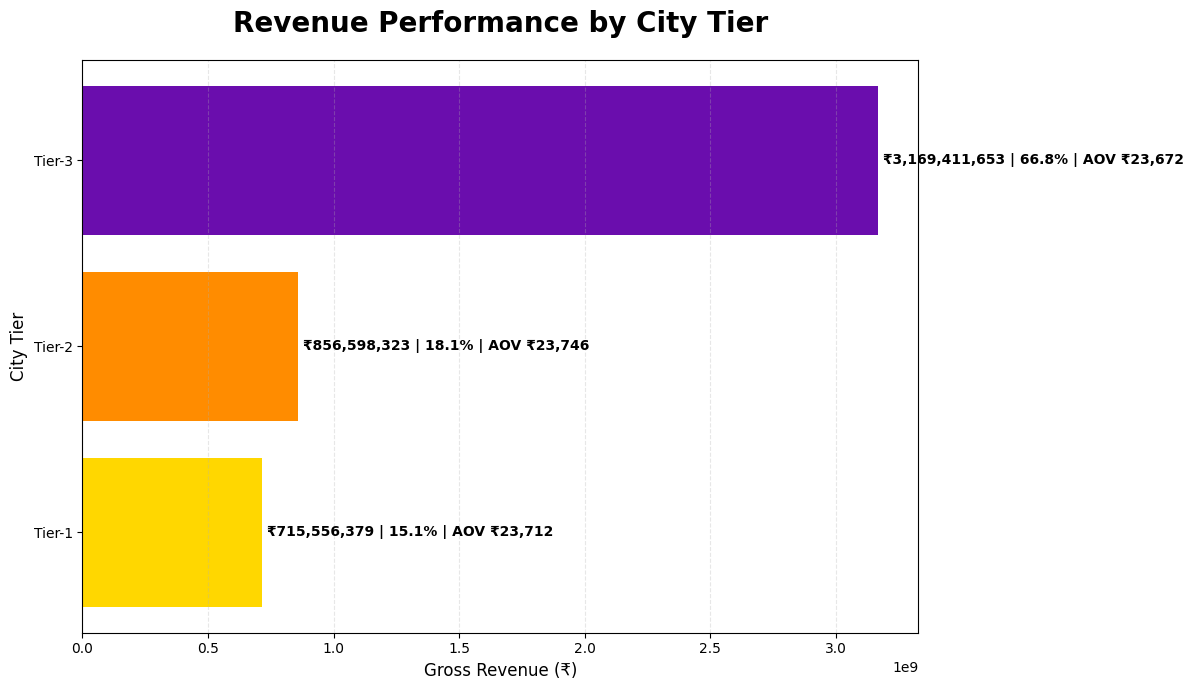

In [0]:
import matplotlib.pyplot as plt

pdf = tier_sales.toPandas()

pdf = pdf.sort_values(
    "Gross_Revenue",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#FFD700", "#FF8C00","#6A0DAD" ]
bars = ax.barh(
    pdf["City_Tier"],
    pdf["Gross_Revenue"],
    color=colors
)

ax.set_title(
    "Revenue Performance by City Tier",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.set_ylabel(
    "City Tier",
    fontsize=12
)

for bar, revenue, aov, share in zip(
    bars,
    pdf["Gross_Revenue"],
    pdf["AOV"],
    pdf["Revenue_Share_Percent"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{revenue:,.0f} | {share:.1f}% | AOV ₹{aov:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
# 8Q.(Top Customers): Who are the top 50 highest-spending customers by aggregate purchase amount, and how many orders do they place on average?

In [0]:
# Q08 - Top Customer Analysis

from pyspark.sql import functions as F
from pyspark.sql.window import Window

customer_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("Customer_ID")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Purchased"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") / F.col("Total_Orders"),
            2
        )
    )
)

display(customer_sales.limit(30))

Customer_ID,Total_Orders,Units_Purchased,Gross_Revenue,AOV
CUST00014303,5,8,319715.47000000003,63943.09
CUST00034253,3,3,218963.05,72987.68
CUST00026507,8,10,473269.13,59158.64
CUST00009418,5,9,539781.79,107956.36
CUST00017326,12,17,509180.85,42431.74
CUST00009627,7,8,154547.02,22078.15
CUST00012719,6,10,356713.08,59452.18
CUST00034189,10,12,324284.26,32428.43
CUST00004378,8,9,116112.88999999998,14514.11
CUST00000924,7,9,10570.82,1510.12


In [0]:
dim_customer = spark.table(
    "workspace.indian_ecommerce_sales_analytics.dim_customer"
)
top_customer_analysis = (
    customer_sales
    .join(
        dim_customer.select(
            "Customer_ID",
            "Customer_Name",
            "Gender",
            "Age",
            "Customer_Tier",
            "City",
            "State"
        ),
        on="Customer_ID",
        how="left"
    )
)

display(top_customer_analysis.limit(25))

Customer_ID,Total_Orders,Units_Purchased,Gross_Revenue,AOV,Customer_Name,Gender,Age,Customer_Tier,City,State
CUST00008468,7,11,490681.32999999996,70097.33,Neha Joshi,Female,32,PLATINUM,Noida,UP
CUST00033715,8,10,253334.71,31666.84,Divya Singh,Female,34,PLATINUM,Varanasi,UP
CUST00024078,5,7,22027.96,4405.59,Arjun Pandey,Male,75,GOLD,Jaipur,Rajasthan
CUST00001261,8,10,284597.04,35574.63,Ananya Kulkarni,Female,33,PLATINUM,Jodhpur,Rajasthan
CUST00019089,13,16,145823.35999999996,11217.18,Sandeep Kaur,Male,22,PLATINUM,Varanasi,UP
CUST00010377,10,12,365655.07,36565.51,Yash Yadav,Male,19,PLATINUM,Faridabad,Haryana
CUST00031061,5,7,35962.13,7192.43,Harleen Singh,Female,36,GOLD,Ahmedabad,Gujarat
CUST00001527,4,6,100407.12,25101.78,Fatima Khan,Female,33,PLATINUM,Vadodara,Gujarat
CUST00011647,9,12,384881.85,42764.65,Amandeep Gill,Male,28,PLATINUM,Durgapur,West Bengal
CUST00000182,14,14,214908.39999999997,15350.6,Megha Yadav,Female,40,PLATINUM,Jodhpur,Rajasthan


In [0]:
customer_window = Window.orderBy(
    F.desc("Gross_Revenue")
)

top_customer_analysis = (
    top_customer_analysis
    .withColumn(
        "Customer_Rank",
        F.row_number().over(customer_window)
    )
)

display(
    top_customer_analysis
    .orderBy("Customer_Rank")
.limit(30))

Customer_ID,Total_Orders,Units_Purchased,Gross_Revenue,AOV,Customer_Name,Gender,Age,Customer_Tier,City,State,Customer_Rank
CUST00004600,9,13,890131.55,98903.51,Aditya Yadav,Male,37,PLATINUM,Thane,Maharashtra,1
CUST00021066,13,21,876932.74,67456.36,Ananya Shah,Female,43,PLATINUM,Kanpur,UP,2
CUST00009202,12,19,843527.62,70293.97,Priya Gupta,Female,25,PLATINUM,Lucknow,UP,3
CUST00021754,12,15,833959.8700000001,69496.66,Ayesha Sheikh,Female,38,PLATINUM,Delhi NCR,Delhi,4
CUST00033067,9,15,796683.98,88520.44,Rahul Iyer,Male,35,PLATINUM,Nagpur,Maharashtra,5
CUST00003487,8,14,790413.46,98801.68,Swati Mehta,Female,40,PLATINUM,Patiala,Punjab,6
CUST00010421,6,11,781769.62,130294.94,Shreya Tiwari,Female,29,PLATINUM,Chennai,Tamil Nadu,7
CUST00013492,10,17,781727.7300000001,78172.77,Pooja Mehta,Female,24,PLATINUM,Kota,Rajasthan,8
CUST00017168,8,13,771239.9400000001,96404.99,Rohan Pandey,Male,37,PLATINUM,Amritsar,Punjab,9
CUST00004104,9,15,753656.3999999999,83739.6,Nikhil Kulkarni,Male,41,PLATINUM,Patiala,Punjab,10


In [0]:
gold_top_customers = (
    top_customer_analysis
    .filter(F.col("Customer_Rank") <= 50)
    .orderBy("Customer_Rank")
)

display(gold_top_customers)

Customer_ID,Total_Orders,Units_Purchased,Gross_Revenue,AOV,Customer_Name,Gender,Age,Customer_Tier,City,State,Customer_Rank
CUST00004600,9,13,890131.55,98903.51,Aditya Yadav,Male,37,PLATINUM,Thane,Maharashtra,1
CUST00021066,13,21,876932.74,67456.36,Ananya Shah,Female,43,PLATINUM,Kanpur,UP,2
CUST00009202,12,19,843527.62,70293.97,Priya Gupta,Female,25,PLATINUM,Lucknow,UP,3
CUST00021754,12,15,833959.8700000001,69496.66,Ayesha Sheikh,Female,38,PLATINUM,Delhi NCR,Delhi,4
CUST00033067,9,15,796683.98,88520.44,Rahul Iyer,Male,35,PLATINUM,Nagpur,Maharashtra,5
CUST00003487,8,14,790413.46,98801.68,Swati Mehta,Female,40,PLATINUM,Patiala,Punjab,6
CUST00010421,6,11,781769.62,130294.94,Shreya Tiwari,Female,29,PLATINUM,Chennai,Tamil Nadu,7
CUST00013492,10,17,781727.7300000001,78172.77,Pooja Mehta,Female,24,PLATINUM,Kota,Rajasthan,8
CUST00017168,8,13,771239.9400000001,96404.99,Rohan Pandey,Male,37,PLATINUM,Amritsar,Punjab,9
CUST00004104,9,15,753656.3999999999,83739.6,Nikhil Kulkarni,Male,41,PLATINUM,Patiala,Punjab,10


In [0]:
total_revenue = (
    customer_sales
    .agg(
        F.sum("Gross_Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

top50_revenue = (
    gold_top_customers
    .agg(
        F.sum("Gross_Revenue").alias("Top50_Revenue")
    )
    .collect()[0]["Top50_Revenue"]
)

top50_share = (
    top50_revenue / total_revenue * 100
)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Top 50 Customer Revenue: ₹{top50_revenue:,.2f}")
print(f"Top 50 Revenue Share: {top50_share:.2f}%")

Total Revenue: ₹4,741,566,354.41
Top 50 Customer Revenue: ₹36,135,907.23
Top 50 Revenue Share: 0.76%


In [0]:
#Saving gold table
(
    gold_top_customers
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_top_customers"
    )
)

print("gold_top_customers created successfully")

gold_top_customers created successfully


In [0]:
print(
    "Top customers count:",
    gold_top_customers.count()
)

Top customers count: 50


In [0]:
gold_top_customers.select(
    "Customer_Rank",
    "Customer_ID",
    "Customer_Name",
    "Total_Orders",
    "Units_Purchased",
    "Gross_Revenue",
    "AOV"
).orderBy("Customer_Rank").show(50, truncate=False)

+-------------+------------+-----------------+------------+---------------+-----------------+---------+
|Customer_Rank|Customer_ID |Customer_Name    |Total_Orders|Units_Purchased|Gross_Revenue    |AOV      |
+-------------+------------+-----------------+------------+---------------+-----------------+---------+
|1            |CUST00004600|Aditya Yadav     |9           |13             |890131.55        |98903.51 |
|2            |CUST00021066|Ananya Shah      |13          |21             |876932.74        |67456.36 |
|3            |CUST00009202|Priya Gupta      |12          |19             |843527.62        |70293.97 |
|4            |CUST00021754|Ayesha Sheikh    |12          |15             |833959.8700000001|69496.66 |
|5            |CUST00033067|Rahul Iyer       |9           |15             |796683.98        |88520.44 |
|6            |CUST00003487|Swati Mehta      |8           |14             |790413.46        |98801.68 |
|7            |CUST00010421|Shreya Tiwari    |6           |11   

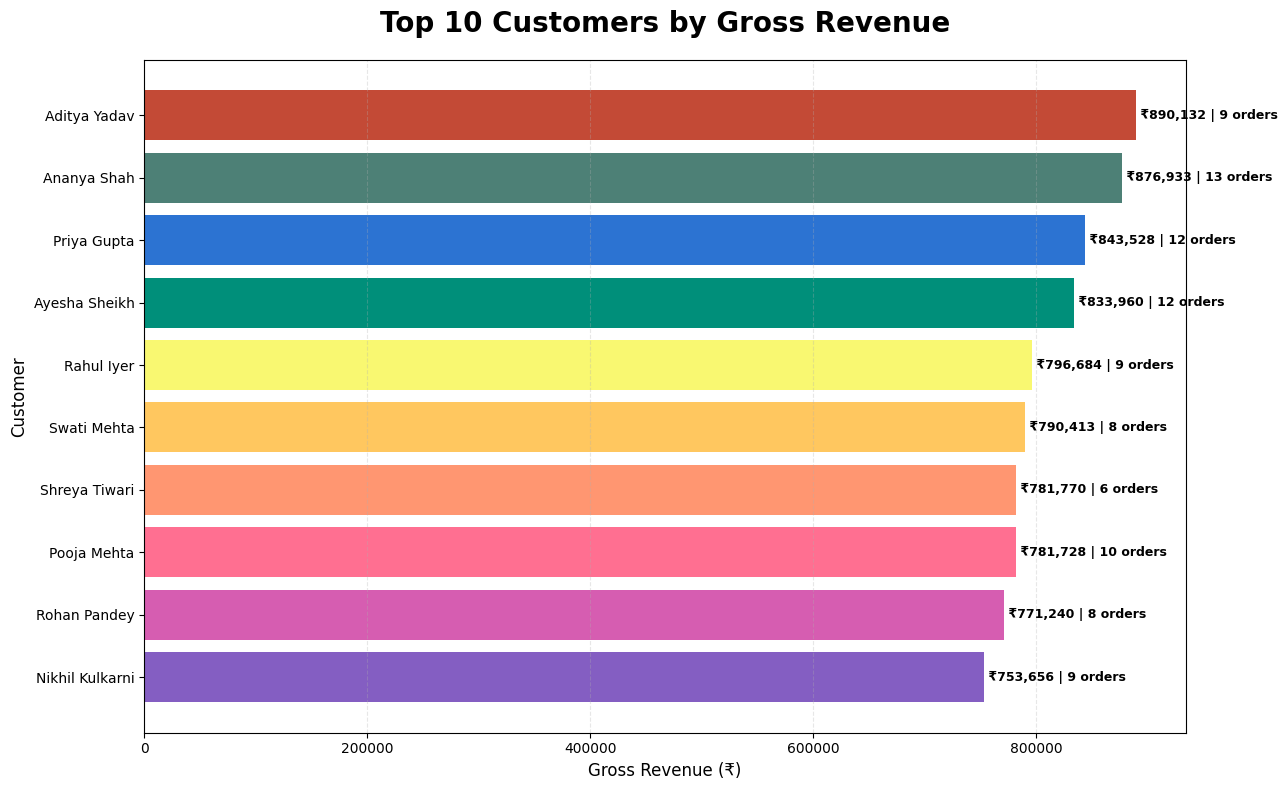

In [0]:
import matplotlib.pyplot as plt

pdf = (
    gold_top_customers
    .orderBy(F.desc("Gross_Revenue"))
    .limit(10)
    .toPandas()
)

pdf = pdf.sort_values(
    "Gross_Revenue",
    ascending=True
)

fig, ax = plt.subplots(figsize=(13, 8))

colors = [
    "#845EC2",
    "#D65DB1",
    "#FF6F91",
    "#FF9671",
    "#FFC75F",
    "#F9F871",
    "#008F7A",
    "#2C73D2",
    "#4D8076",
    "#C34A36"
]

bars = ax.barh(
    pdf["Customer_Name"],
    pdf["Gross_Revenue"],
    color=colors
)

ax.set_title(
    "Top 10 Customers by Gross Revenue",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.set_ylabel(
    "Customer",
    fontsize=12
)

for bar, revenue, orders in zip(
    bars,
    pdf["Gross_Revenue"],
    pdf["Total_Orders"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{revenue:,.0f} | {orders} orders",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
# 9Q.(Best Selling Products): Which top 10 unique products generate the highest volume of single-unit sales and total revenue value?

In [0]:
# Q09 - Best-Selling Product Analysis

from pyspark.sql import functions as F
from pyspark.sql.window import Window

product_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("Product_ID")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
)

display(product_sales.limit(30))

Product_ID,Total_Orders,Units_Sold,Gross_Revenue
PROD001017,187,237,612717.7900000003
PROD000703,161,200,1.7906187199999996E7
PROD000213,182,224,7554631.7799999835
PROD001437,186,230,1.570781825999999E7
PROD001392,67,81,92048.82
PROD001876,90,118,2622141.3799999966
PROD000214,172,212,1.8229328200000063E7
PROD000803,109,146,74262.79000000004
PROD000636,143,169,660926.8399999996
PROD001923,89,109,136016.53999999998


In [0]:
dim_product = spark.table(
    "workspace.indian_ecommerce_sales_analytics.dim_product"
)


product_analysis = (
    product_sales
    .join(
        dim_product.select(
            "Product_ID",
            "Product_Name",
            "Category",
            "Brand",
            "Selling_Price",
            "Original_Price",
            "Discount_Percent",
            "Avg_Rating"
        ),
        on="Product_ID",
        how="left"
    )
    .withColumn(
        "Revenue_Per_Unit",
        F.round(
            F.col("Gross_Revenue") / F.col("Units_Sold"),
            2
        )
    )
)

display(product_analysis.limit(25))

Product_ID,Total_Orders,Units_Sold,Gross_Revenue,Product_Name,Category,Brand,Selling_Price,Original_Price,Discount_Percent,Avg_Rating,Revenue_Per_Unit
PROD001160,187,250,1.0061679239999983E7,Apple iPhone V1,Electronics,Apple,40693.81,57315.23,29.0,4.43,40246.72
PROD000865,77,97,1451108.9900000019,Dumbbells V3,Sports,Dumbbells,15138.78,19408.69,22.0,4.32,14959.89
PROD000418,82,107,189020.27999999982,Lays Chips V9,Grocery,Lays,1803.9,2818.6,36.0,4.36,1766.54
PROD001880,73,85,2532980.2,Dumbbells V4,Sports,Dumbbells,30020.5,34114.21,12.0,4.4,29799.77
PROD000707,161,203,775979.34,Peter England Shirt V2,Fashion,Peter,3862.54,7725.08,50.0,4.44,3822.56
PROD000712,102,130,3252946.869999995,Prestige Cooker V5,Home,Prestige,25358.9,42981.18,41.0,4.46,25022.67
PROD000073,145,179,1.3258341979999963E7,boAt Headphones V4,Electronics,Boat,74659.02,106655.74,30.0,4.35,74068.95
PROD000878,203,258,1.1954807189999972E7,boAt Headphones V9,Electronics,Boat,46813.85,83596.16,44.0,4.33,46336.46
PROD001431,107,134,22584.42,Aashirvaad Atta V1,Grocery,Aashirvaad,121.71,187.25,35.0,4.43,168.54
PROD001233,151,180,2116804.5100000026,Nike Shoes V6,Fashion,Nike,11826.1,14969.75,21.0,4.38,11760.03


In [0]:
revenue_window = Window.orderBy(
    F.desc("Gross_Revenue")
)

product_analysis = (
    product_analysis
    .withColumn(
        "Revenue_Rank",
        F.row_number().over(revenue_window)
    )
)

display(
    product_analysis
    .orderBy("Revenue_Rank")
.limit(25))

Product_ID,Total_Orders,Units_Sold,Gross_Revenue,Product_Name,Category,Brand,Selling_Price,Original_Price,Discount_Percent,Avg_Rating,Revenue_Per_Unit,Revenue_Rank
PROD001366,193,246,3.115813378000005E7,Samsung Mobile V4,Electronics,Samsung,127597.19,134312.83,5.0,4.49,126659.08,1
PROD001405,205,254,3.0968757560000017E7,Apple iPhone V3,Electronics,Apple,123191.16,144930.78,15.0,4.39,121924.24,2
PROD000250,182,224,3.047526594999989E7,Apple iPhone V9,Electronics,Apple,136973.33,148884.05,8.0,4.36,136050.29,3
PROD000495,199,248,2.913711249000004E7,Apple iPhone V8,Electronics,Apple,118739.66,146592.17,19.0,4.38,117488.36,4
PROD000772,199,253,2.8154401310000073E7,HP Laptop V2,Electronics,Hp,112802.89,128185.1,12.0,4.3,111282.22,5
PROD000144,194,247,2.73925407599999E7,Noise Watch V4,Electronics,Noise,111947.04,117838.99,5.0,4.42,110900.97,6
PROD000039,188,241,2.667418753000004E7,Noise Watch V1,Electronics,Noise,111661.94,139577.42,20.0,4.39,110681.28,7
PROD001683,197,248,2.646336221000001E7,boAt Headphones V9,Electronics,Boat,107536.62,143382.16,25.0,4.41,106707.11,8
PROD001298,197,242,2.643685610999997E7,boAt Headphones V8,Electronics,Boat,110483.31,124138.55,11.0,4.36,109243.21,9
PROD000947,178,225,2.642790340000004E7,HP Laptop V5,Electronics,Hp,118943.76,125203.96,5.0,4.42,117457.35,10


In [0]:
units_window = Window.orderBy(
    F.desc("Units_Sold")
)

product_analysis = (
    product_analysis
    .withColumn(
        "Units_Rank",
        F.row_number().over(units_window)
    )
)

display(product_analysis.limit(25))

Product_ID,Total_Orders,Units_Sold,Gross_Revenue,Product_Name,Category,Brand,Selling_Price,Original_Price,Discount_Percent,Avg_Rating,Revenue_Per_Unit,Revenue_Rank,Units_Rank
PROD000176,219,275,1.2084141360000018E7,Samsung Mobile V7,Electronics,Samsung,44316.8,82068.15,46.0,4.5,43942.33,138,1
PROD001891,205,269,6285425.780000011,Samsung Mobile V1,Electronics,Samsung,23556.11,46188.45,49.0,4.45,23365.9,214,2
PROD000914,215,268,1278863.9499999979,Noise Watch V5,Electronics,Noise,4825.91,6434.55,25.0,4.39,4771.88,681,3
PROD001615,215,266,3277532.2799999914,Apple iPhone V5,Electronics,Apple,12426.42,19724.48,37.0,4.37,12321.55,297,4
PROD000246,211,265,8377145.08999999,Samsung Mobile V7,Electronics,Samsung,31895.68,47605.49,33.0,4.42,31611.87,189,5
PROD001053,203,262,2559656.1800000067,boAt Headphones V8,Electronics,Boat,9843.99,15381.24,36.0,4.37,9769.68,379,6
PROD000949,214,261,1.6251911299999945E7,Noise Watch V7,Electronics,Noise,62754.87,67478.36,7.0,4.39,62267.86,74,7
PROD000074,212,261,1.3360383710000038E7,Noise Watch V7,Electronics,Noise,51771.15,60907.24,15.0,4.44,51189.21,121,8
PROD000004,207,261,1.116001308E7,Noise Watch V7,Electronics,Noise,43075.89,81275.27,47.0,4.42,42758.67,151,9
PROD001297,212,260,1.6697159400000038E7,HP Laptop V4,Electronics,Hp,65103.74,75702.02,14.0,4.41,64219.84,69,10


In [0]:
total_revenue = (
    product_sales
    .agg(
        F.sum("Gross_Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

product_analysis = (
    product_analysis
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") /
            F.lit(total_revenue) * 100,
            2
        )
    )
)

display(product_analysis.limit(30))

Product_ID,Total_Orders,Units_Sold,Gross_Revenue,Product_Name,Category,Brand,Selling_Price,Original_Price,Discount_Percent,Avg_Rating,Revenue_Per_Unit,Revenue_Rank,Units_Rank,Revenue_Share_Percent
PROD000176,219,275,1.2084141360000018E7,Samsung Mobile V7,Electronics,Samsung,44316.8,82068.15,46.0,4.5,43942.33,138,1,0.25
PROD001891,205,269,6285425.780000011,Samsung Mobile V1,Electronics,Samsung,23556.11,46188.45,49.0,4.45,23365.9,214,2,0.13
PROD000914,215,268,1278863.9499999979,Noise Watch V5,Electronics,Noise,4825.91,6434.55,25.0,4.39,4771.88,681,3,0.03
PROD001615,215,266,3277532.2799999914,Apple iPhone V5,Electronics,Apple,12426.42,19724.48,37.0,4.37,12321.55,297,4,0.07
PROD000246,211,265,8377145.08999999,Samsung Mobile V7,Electronics,Samsung,31895.68,47605.49,33.0,4.42,31611.87,189,5,0.18
PROD001053,203,262,2559656.1800000067,boAt Headphones V8,Electronics,Boat,9843.99,15381.24,36.0,4.37,9769.68,379,6,0.05
PROD000004,207,261,1.116001308E7,Noise Watch V7,Electronics,Noise,43075.89,81275.27,47.0,4.42,42758.67,151,7,0.24
PROD000074,212,261,1.3360383710000038E7,Noise Watch V7,Electronics,Noise,51771.15,60907.24,15.0,4.44,51189.21,121,8,0.28
PROD000949,214,261,1.6251911299999945E7,Noise Watch V7,Electronics,Noise,62754.87,67478.36,7.0,4.39,62267.86,74,9,0.34
PROD001297,212,260,1.6697159400000038E7,HP Laptop V4,Electronics,Hp,65103.74,75702.02,14.0,4.41,64219.84,69,10,0.35


In [0]:
#Creating Final Gold table
gold_best_selling_products = (
    product_analysis
    .orderBy("Revenue_Rank")
)

(
    gold_best_selling_products
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_best_selling_products"
    )
)

print(
    "gold_best_selling_products created successfully"
)

gold_best_selling_products created successfully


In [0]:
top_10_revenue_products = (
    gold_best_selling_products
    .filter(F.col("Revenue_Rank") <= 10)
    .orderBy("Revenue_Rank")
)

display(
    top_10_revenue_products.select(
        "Revenue_Rank",
        "Product_ID",
        "Product_Name",
        "Category",
        "Brand",
        "Units_Sold",
        "Gross_Revenue",
        "Revenue_Share_Percent",
        "Revenue_Per_Unit"
    )
)

Revenue_Rank,Product_ID,Product_Name,Category,Brand,Units_Sold,Gross_Revenue,Revenue_Share_Percent,Revenue_Per_Unit
1,PROD001366,Samsung Mobile V4,Electronics,Samsung,246,3.115813378000005E7,0.66,126659.08
2,PROD001405,Apple iPhone V3,Electronics,Apple,254,3.0968757560000017E7,0.65,121924.24
3,PROD000250,Apple iPhone V9,Electronics,Apple,224,3.047526594999989E7,0.64,136050.29
4,PROD000495,Apple iPhone V8,Electronics,Apple,248,2.913711249000004E7,0.61,117488.36
5,PROD000772,HP Laptop V2,Electronics,Hp,253,2.8154401310000073E7,0.59,111282.22
6,PROD000144,Noise Watch V4,Electronics,Noise,247,2.73925407599999E7,0.58,110900.97
7,PROD000039,Noise Watch V1,Electronics,Noise,241,2.667418753000004E7,0.56,110681.28
8,PROD001683,boAt Headphones V9,Electronics,Boat,248,2.646336221000001E7,0.56,106707.11
9,PROD001298,boAt Headphones V8,Electronics,Boat,242,2.643685610999997E7,0.56,109243.21
10,PROD000947,HP Laptop V5,Electronics,Hp,225,2.642790340000004E7,0.56,117457.35


In [0]:
top_10_units_products = (
    gold_best_selling_products
    .filter(F.col("Units_Rank") <= 10)
    .orderBy("Units_Rank")
)

display(
    top_10_units_products.select(
        "Units_Rank",
        "Product_ID",
        "Product_Name",
        "Category",
        "Brand",
        "Units_Sold",
        "Gross_Revenue",
        "Revenue_Per_Unit"
    )
)

Units_Rank,Product_ID,Product_Name,Category,Brand,Units_Sold,Gross_Revenue,Revenue_Per_Unit
1,PROD000176,Samsung Mobile V7,Electronics,Samsung,275,1.2084141360000018E7,43942.33
2,PROD001891,Samsung Mobile V1,Electronics,Samsung,269,6285425.780000011,23365.9
3,PROD000914,Noise Watch V5,Electronics,Noise,268,1278863.9499999979,4771.88
4,PROD001615,Apple iPhone V5,Electronics,Apple,266,3277532.2799999914,12321.55
5,PROD000246,Samsung Mobile V7,Electronics,Samsung,265,8377145.08999999,31611.87
6,PROD001053,boAt Headphones V8,Electronics,Boat,262,2559656.1800000067,9769.68
7,PROD000949,Noise Watch V7,Electronics,Noise,261,1.6251911299999945E7,62267.86
8,PROD000074,Noise Watch V7,Electronics,Noise,261,1.3360383710000038E7,51189.21
9,PROD000004,Noise Watch V7,Electronics,Noise,261,1.116001308E7,42758.67
10,PROD001297,HP Laptop V4,Electronics,Hp,260,1.6697159400000038E7,64219.84


In [0]:
print(
    "Products analyzed:",
    gold_best_selling_products.count()
)
gold_best_selling_products.agg(
    F.sum("Gross_Revenue").alias("Total_Product_Revenue")
).show()

Products analyzed: 2000
+---------------------+
|Total_Product_Revenue|
+---------------------+
|  4.741566354409998E9|
+---------------------+



In [0]:
gold_best_selling_products.agg(
    F.sum("Units_Sold").alias("Total_Product_Units")
).show()

+-------------------+
|Total_Product_Units|
+-------------------+
|             249834|
+-------------------+



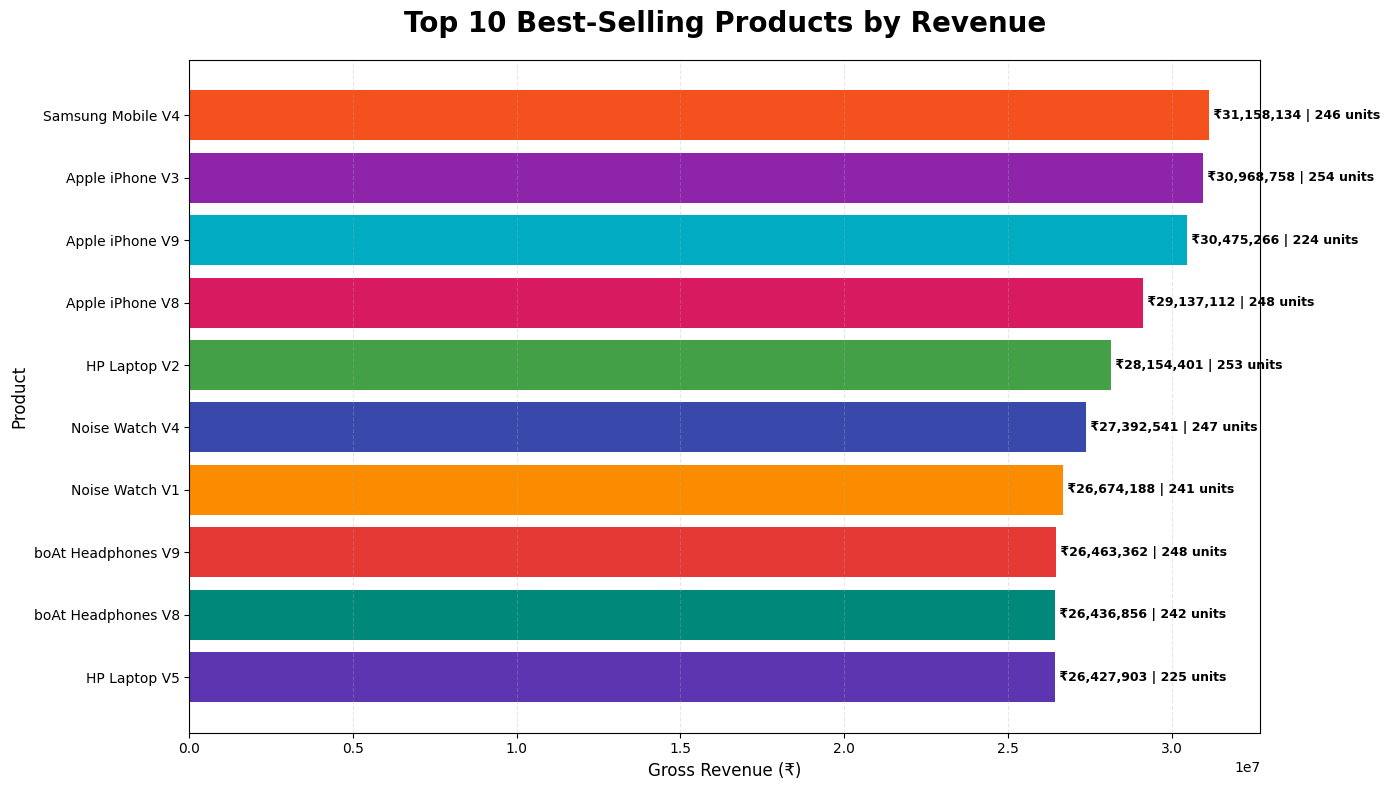

In [0]:
import matplotlib.pyplot as plt

pdf = (
    top_10_revenue_products
    .toPandas()
    .sort_values(
        "Gross_Revenue",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    "#5E35B1",
    "#00897B",
    "#E53935",
    "#FB8C00",
    "#3949AB",
    "#43A047",
    "#D81B60",
    "#00ACC1",
    "#8E24AA",
    "#F4511E"
]

bars = ax.barh(
    pdf["Product_Name"],
    pdf["Gross_Revenue"],
    color=colors
)

ax.set_title(
    "Top 10 Best-Selling Products by Revenue",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.set_ylabel(
    "Product",
    fontsize=12
)

for bar, revenue, units in zip(
    bars,
    pdf["Gross_Revenue"],
    pdf["Units_Sold"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{revenue:,.0f} | {units:,} units",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
#10Q.(Category Performance): Which macro product categories (e.g., Electronics, Apparel, Home Decor) yield the highest sales volumes, and which have lagging turnover rates?

In [0]:
# Q10 - Category Performance Analysis

from pyspark.sql import functions as F

category_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("Product_ID")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
    .join(
        dim_product.select(
            "Product_ID",
            "Category"
        ),
        on="Product_ID",
        how="left"
    )
    .groupBy("Category")
    .agg(
        F.sum("Total_Orders").alias("Total_Orders"),
        F.sum("Units_Sold").alias("Units_Sold"),
        F.sum("Gross_Revenue").alias("Gross_Revenue")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") /
            F.col("Total_Orders"),
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(category_sales)

Category,Total_Orders,Units_Sold,Gross_Revenue,AOV
Electronics,53576,66757,3.443287971179999E9,64269.22
Home,26877,33680,5.7328601419E8,21329.99
Sports,23410,29318,3.7939182328999996E8,16206.4
Fashion,39842,49807,2.665793967799999E8,6690.91
Grocery,26778,33346,3.3458775099999998E7,1249.49
Beauty,13427,16734,3.0659050750000007E7,2283.39
Books,16229,20192,1.4903323120000001E7,918.31


In [0]:
total_category_revenue = (
    category_sales
    .agg(
        F.sum("Gross_Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

category_sales = (
    category_sales
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") /
            F.lit(total_category_revenue) * 100,
            2
        )
    )
)

display(category_sales)

Category,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent
Electronics,53576,66757,3.443287971179999E9,64269.22,72.62
Home,26877,33680,5.7328601419E8,21329.99,12.09
Sports,23410,29318,3.7939182328999996E8,16206.4,8.0
Fashion,39842,49807,2.665793967799999E8,6690.91,5.62
Grocery,26778,33346,3.3458775099999998E7,1249.49,0.71
Beauty,13427,16734,3.0659050750000007E7,2283.39,0.65
Books,16229,20192,1.4903323120000001E7,918.31,0.31


In [0]:
from pyspark.sql.window import Window

revenue_window = Window.orderBy(
    F.desc("Gross_Revenue")
)

units_window = Window.orderBy(
    F.desc("Units_Sold")
)

category_sales = (
    category_sales
    .withColumn(
        "Revenue_Rank",
        F.row_number().over(revenue_window)
    )
    .withColumn(
        "Units_Rank",
        F.row_number().over(units_window)
    )
)

display(
    category_sales.orderBy("Revenue_Rank")
)

Category,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent,Revenue_Rank,Units_Rank
Electronics,53576,66757,3.443287971179999E9,64269.22,72.62,1,1
Home,26877,33680,5.7328601419E8,21329.99,12.09,2,3
Sports,23410,29318,3.7939182328999996E8,16206.4,8.0,3,5
Fashion,39842,49807,2.665793967799999E8,6690.91,5.62,4,2
Grocery,26778,33346,3.3458775099999998E7,1249.49,0.71,5,4
Beauty,13427,16734,3.0659050750000007E7,2283.39,0.65,6,7
Books,16229,20192,1.4903323120000001E7,918.31,0.31,7,6


In [0]:
top_categories = (
    category_sales
    .orderBy(F.desc("Gross_Revenue"))
    .limit(5)
)

display(top_categories)

Category,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent,Revenue_Rank,Units_Rank
Electronics,53576,66757,3.443287971179999E9,64269.22,72.62,1,1
Home,26877,33680,5.7328601419E8,21329.99,12.09,2,3
Sports,23410,29318,3.7939182328999996E8,16206.4,8.0,3,5
Fashion,39842,49807,2.665793967799999E8,6690.91,5.62,4,2
Grocery,26778,33346,3.3458775099999998E7,1249.49,0.71,5,4


In [0]:
lagging_categories = (
    category_sales
    .orderBy(F.asc("Gross_Revenue"))
    .limit(5)
)

display(lagging_categories)

Category,Total_Orders,Units_Sold,Gross_Revenue,AOV,Revenue_Share_Percent,Revenue_Rank,Units_Rank
Books,16229,20192,1.4903323120000001E7,918.31,0.31,7,6
Beauty,13427,16734,3.0659050750000007E7,2283.39,0.65,6,7
Grocery,26778,33346,3.3458775099999998E7,1249.49,0.71,5,4
Fashion,39842,49807,2.665793967799999E8,6690.91,5.62,4,2
Sports,23410,29318,3.7939182328999996E8,16206.4,8.0,3,5


In [0]:
gold_category_performance = category_sales

(
    gold_category_performance
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_category_performance"
    )
)

print(
    "gold_category_performance created successfully"
)

gold_category_performance created successfully


In [0]:
print(
    "Categories analyzed:",
    gold_category_performance.count()
)

Categories analyzed: 7


In [0]:
gold_category_performance.agg(
    F.sum("Gross_Revenue").alias("Total_Category_Revenue")
).show()

+----------------------+
|Total_Category_Revenue|
+----------------------+
|       4.74156635441E9|
+----------------------+



In [0]:
gold_category_performance.agg(
    F.sum("Units_Sold").alias("Total_Category_Units")
).show()

+--------------------+
|Total_Category_Units|
+--------------------+
|              249834|
+--------------------+



In [0]:
gold_category_performance.agg(
    F.sum("Revenue_Share_Percent").alias("Total_Revenue_Share")
).show()

+-------------------+
|Total_Revenue_Share|
+-------------------+
| 100.00000000000001|
+-------------------+



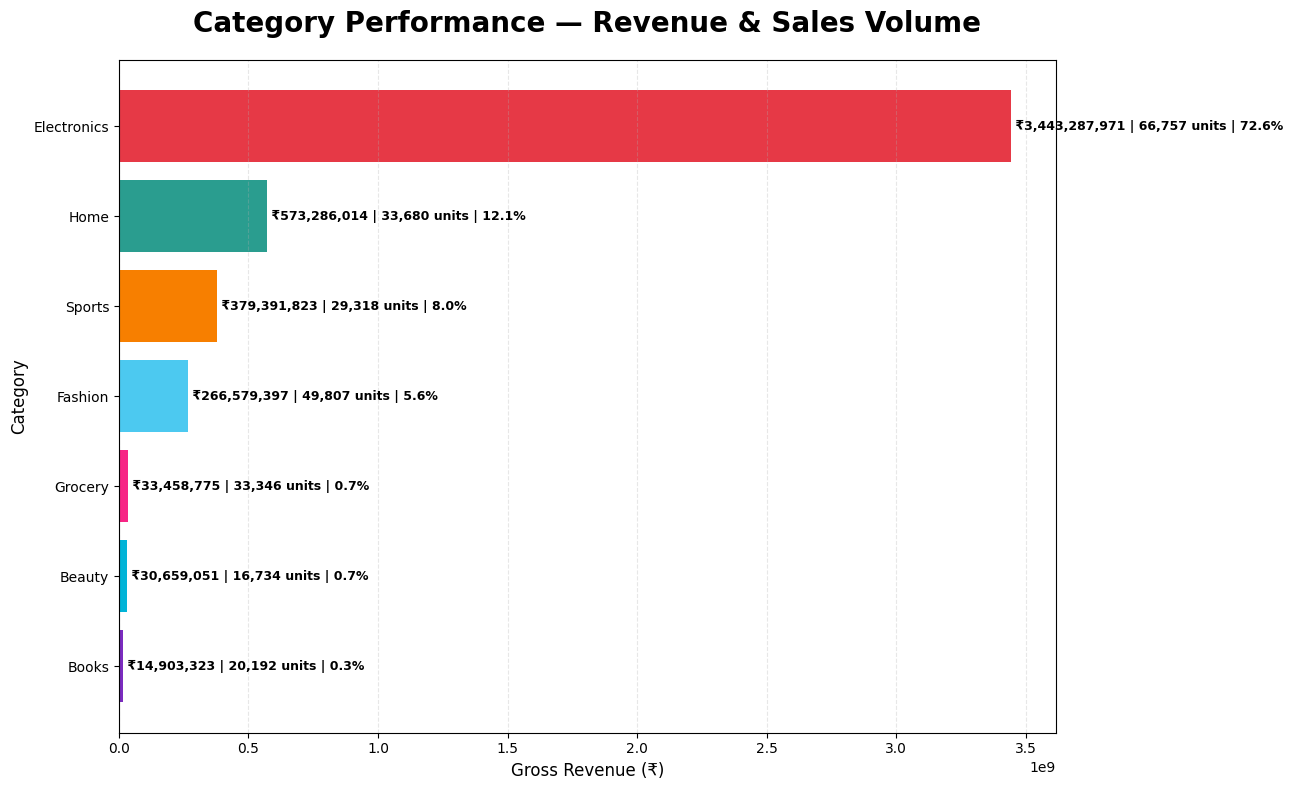

In [0]:
import matplotlib.pyplot as plt

pdf = (
    gold_category_performance
    .orderBy(F.desc("Gross_Revenue"))
    .toPandas()
)

pdf = pdf.sort_values(
    "Gross_Revenue",
    ascending=True
)

fig, ax = plt.subplots(figsize=(13, 8))

colors = [
    "#7B2CBF",
    "#00B4D8",
    "#F72585",
    "#4CC9F0",
    "#F77F00",
    "#2A9D8F",
    "#E63946",
    "#6A994E",
    "#FFB703",
    "#8338EC"
]

bars = ax.barh(
    pdf["Category"],
    pdf["Gross_Revenue"],
    color=colors[:len(pdf)]
)

ax.set_title(
    "Category Performance — Revenue & Sales Volume",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.set_ylabel(
    "Category",
    fontsize=12
)

for bar, revenue, units, share in zip(
    bars,
    pdf["Gross_Revenue"],
    pdf["Units_Sold"],
    pdf["Revenue_Share_Percent"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{revenue:,.0f} | {units:,} units | {share:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
# Q11.(Brand Performance): Which specific consumer brands dominate our overall catalog revenue, and are there brands with high sale volumes but low overall value margins?

In [0]:
# Q11 - Brand Performance Analysis

from pyspark.sql import functions as F
from pyspark.sql.window import Window

brand_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("Product_ID")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
    .join(
        dim_product.select(
            "Product_ID",
            "Brand",
            "Category",
            "Selling_Price",
            "Original_Price",
            "Discount_Percent"
        ),
        on="Product_ID",
        how="left"
    )
    .groupBy("Brand")
    .agg(
        F.sum("Total_Orders").alias("Total_Orders"),
        F.sum("Units_Sold").alias("Units_Sold"),
        F.sum("Gross_Revenue").alias("Gross_Revenue")
    )
    .withColumn(
        "Revenue_Per_Unit",
        F.round(
            F.col("Gross_Revenue") / F.col("Units_Sold"),
            2
        )
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") / F.col("Total_Orders"),
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(brand_sales)

Brand,Total_Orders,Units_Sold,Gross_Revenue,Revenue_Per_Unit,AOV
Hp,10744,13328,7.5493233537E8,56642.58,70265.48
Noise,10743,13453,7.2952809179E8,54227.91,67907.3
Boat,10704,13314,6.724491294799995E8,50506.92,62822.23
Samsung,10676,13308,6.702877226299999E8,50367.28,62784.54
Apple,10709,13354,6.160906919099997E8,46135.29,57530.18
Nike,12660,15930,1.3957975229E8,8762.07,11025.26
Puma,12962,16145,1.2981248541000003E8,8040.41,10014.85
Urban,5332,6695,1.2170637673999996E8,18178.7,22825.65
Godrej,5402,6691,1.2019053108000004E8,17963.01,22249.27
Philips,5402,6785,1.1428447961999999E8,16843.7,21155.96


In [0]:
#Revenue share
total_brand_revenue = (
    brand_sales
    .agg(
        F.sum("Gross_Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

brand_sales = (
    brand_sales
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") /
            F.lit(total_brand_revenue) * 100,
            2
        )
    )
)

display(brand_sales)

Brand,Total_Orders,Units_Sold,Gross_Revenue,Revenue_Per_Unit,AOV,Revenue_Share_Percent
Hp,10744,13328,7.5493233537E8,56642.58,70265.48,15.92
Noise,10743,13453,7.2952809179E8,54227.91,67907.3,15.39
Boat,10704,13314,6.724491294799995E8,50506.92,62822.23,14.18
Samsung,10676,13308,6.702877226299999E8,50367.28,62784.54,14.14
Apple,10709,13354,6.160906919099997E8,46135.29,57530.18,12.99
Nike,12660,15930,1.3957975229E8,8762.07,11025.26,2.94
Puma,12962,16145,1.2981248541000003E8,8040.41,10014.85,2.74
Urban,5332,6695,1.2170637673999996E8,18178.7,22825.65,2.57
Godrej,5402,6691,1.2019053108000004E8,17963.01,22249.27,2.53
Philips,5402,6785,1.1428447961999999E8,16843.7,21155.96,2.41


In [0]:
#Rank Brands
revenue_window = Window.orderBy(
    F.desc("Gross_Revenue")
)

units_window = Window.orderBy(
    F.desc("Units_Sold")
)

brand_sales = (
    brand_sales
    .withColumn(
        "Revenue_Rank",
        F.row_number().over(revenue_window)
    )
    .withColumn(
        "Units_Rank",
        F.row_number().over(units_window)
    )
)

display(
    brand_sales.orderBy("Revenue_Rank")
)

Brand,Total_Orders,Units_Sold,Gross_Revenue,Revenue_Per_Unit,AOV,Revenue_Share_Percent,Revenue_Rank,Units_Rank
Hp,10744,13328,7.5493233537E8,56642.58,70265.48,15.92,1,5
Noise,10743,13453,7.2952809179E8,54227.91,67907.3,15.39,2,3
Boat,10704,13314,6.724491294799995E8,50506.92,62822.23,14.18,3,6
Samsung,10676,13308,6.702877226299999E8,50367.28,62784.54,14.14,4,7
Apple,10709,13354,6.160906919099997E8,46135.29,57530.18,12.99,5,4
Nike,12660,15930,1.3957975229E8,8762.07,11025.26,2.94,6,2
Puma,12962,16145,1.2981248541000003E8,8040.41,10014.85,2.74,7,1
Urban,5332,6695,1.2170637673999996E8,18178.7,22825.65,2.57,8,15
Godrej,5402,6691,1.2019053108000004E8,17963.01,22249.27,2.53,9,16
Philips,5402,6785,1.1428447961999999E8,16843.7,21155.96,2.41,10,12


In [0]:
#Top 10 brands
top_10_brands = (
    brand_sales
    .orderBy(F.desc("Gross_Revenue"))
    .limit(10)
)

display(top_10_brands)

Brand,Total_Orders,Units_Sold,Gross_Revenue,Revenue_Per_Unit,AOV,Revenue_Share_Percent,Revenue_Rank,Units_Rank
Hp,10744,13328,7.5493233537E8,56642.58,70265.48,15.92,1,5
Noise,10743,13453,7.2952809179E8,54227.91,67907.3,15.39,2,3
Boat,10704,13314,6.724491294799995E8,50506.92,62822.23,14.18,3,6
Samsung,10676,13308,6.702877226299999E8,50367.28,62784.54,14.14,4,7
Apple,10709,13354,6.160906919099997E8,46135.29,57530.18,12.99,5,4
Nike,12660,15930,1.3957975229E8,8762.07,11025.26,2.94,6,2
Puma,12962,16145,1.2981248541000003E8,8040.41,10014.85,2.74,7,1
Urban,5332,6695,1.2170637673999996E8,18178.7,22825.65,2.57,8,15
Godrej,5402,6691,1.2019053108000004E8,17963.01,22249.27,2.53,9,16
Philips,5402,6785,1.1428447961999999E8,16843.7,21155.96,2.41,10,12


In [0]:
# High volume ,lower volume brands
overall_rpu = (
    brand_sales
    .agg(
        F.avg("Revenue_Per_Unit").alias("Avg_Revenue_Per_Unit")
    )
    .collect()[0]["Avg_Revenue_Per_Unit"]
)

print(
    f"Overall Average Revenue per Unit: ₹{overall_rpu:,.2f}"
)

Overall Average Revenue per Unit: ₹13,083.08


In [0]:
# Identify high-volume / low-value brands

# Calculate average units sold across all brands
overall_avg_units = (
    brand_sales
    .agg(
        F.avg("Units_Sold").alias("Avg_Units_Sold")
    )
    .collect()[0]["Avg_Units_Sold"]
)

# Calculate average revenue per unit
overall_rpu = (
    brand_sales
    .agg(
        F.avg("Revenue_Per_Unit").alias("Avg_Revenue_Per_Unit")
    )
    .collect()[0]["Avg_Revenue_Per_Unit"]
)

print(f"Average Units Sold per Brand: {overall_avg_units:,.2f}")
print(f"Average Revenue per Unit: ₹{overall_rpu:,.2f}")

# High-volume + low-value brands
high_volume_low_value = (
    brand_sales
    .filter(
        (F.col("Units_Sold") > F.lit(overall_avg_units)) &
        (F.col("Revenue_Per_Unit") < F.lit(overall_rpu))
    )
    .orderBy(F.desc("Units_Sold"))
)

display(high_volume_low_value)

Average Units Sold per Brand: 7,570.73
Average Revenue per Unit: ₹13,083.08


Brand,Total_Orders,Units_Sold,Gross_Revenue,Revenue_Per_Unit,AOV,Revenue_Share_Percent,Revenue_Rank,Units_Rank
Puma,12962,16145,1.2981248541000003E8,8040.41,10014.85,2.74,7,1
Nike,12660,15930,1.3957975229E8,8762.07,11025.26,2.94,6,2
Peter,8100,10132,5.591088194000002E7,5518.25,6902.58,1.18,16,8
Levis,7847,9784,5.026175034E7,5137.14,6405.22,1.06,17,9
Titan,7768,9696,4.531758690000002E7,4673.84,5833.88,0.96,18,10


In [0]:
# Saving to Gold table
gold_brand_performance = brand_sales

(
    gold_brand_performance
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_brand_performance"
    )
)

print(
    "gold_brand_performance created successfully"
)

gold_brand_performance created successfully


In [0]:
print(
    "Brands analyzed:",
    gold_brand_performance.select("Brand").distinct().count()
)

Brands analyzed: 33


In [0]:
gold_brand_performance.agg(
    F.sum("Gross_Revenue").alias("Total_Brand_Revenue")
).show()

+-------------------+
|Total_Brand_Revenue|
+-------------------+
|4.741566354409997E9|
+-------------------+



In [0]:
gold_brand_performance.agg(
    F.sum("Units_Sold").alias("Total_Brand_Units")
).show()

+-----------------+
|Total_Brand_Units|
+-----------------+
|           249834|
+-----------------+



In [0]:
gold_brand_performance.agg(
    F.sum("Revenue_Share_Percent").alias("Total_Revenue_Share")
).show()

+-------------------+
|Total_Revenue_Share|
+-------------------+
|  99.99999999999997|
+-------------------+



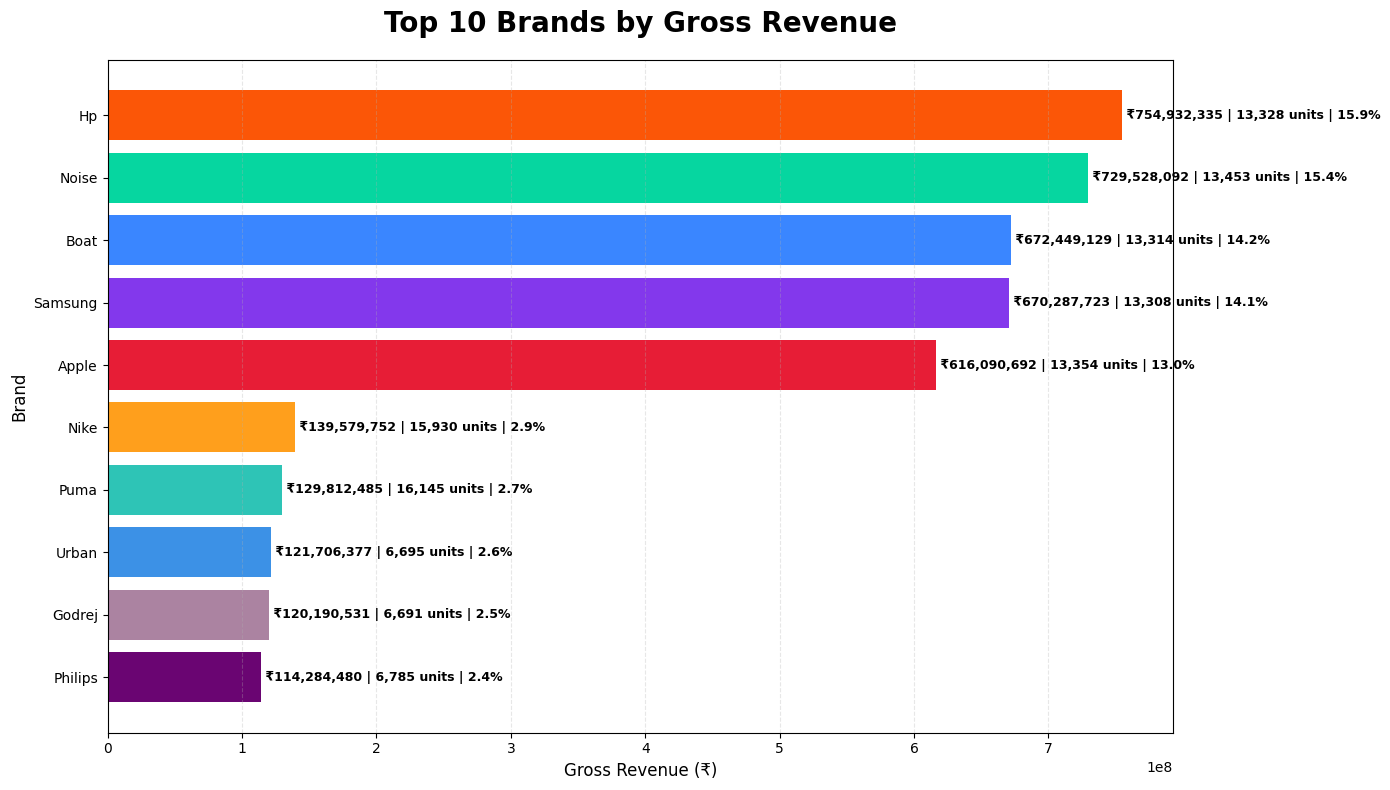

In [0]:
import matplotlib.pyplot as plt

pdf = (
    top_10_brands
    .toPandas()
    .sort_values(
        "Gross_Revenue",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    "#6A0572",
    "#AB83A1",
    "#3C91E6",
    "#2EC4B6",
    "#FF9F1C",
    "#E71D36",
    "#8338EC",
    "#3A86FF",
    "#06D6A0",
    "#FB5607"
]

bars = ax.barh(
    pdf["Brand"],
    pdf["Gross_Revenue"],
    color=colors
)

ax.set_title(
    "Top 10 Brands by Gross Revenue",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.set_ylabel(
    "Brand",
    fontsize=12
)

for bar, revenue, units, share in zip(
    bars,
    pdf["Gross_Revenue"],
    pdf["Units_Sold"],
    pdf["Revenue_Share_Percent"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{revenue:,.0f} | {units:,} units | {share:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
# Q12.12. (Product Ratings): What is the average rating across different product categories, and is there a direct positive correlation between high review scores and sales volumes?


In [0]:
# Q12 - Product Ratings & Rating-Sales Correlation

from pyspark.sql import functions as F

product_rating_sales = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .groupBy("Product_ID")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue")
    )
    .join(
        dim_product.select(
            "Product_ID",
            "Product_Name",
            "Category",
            "Brand",
            "Avg_Rating",
            "Total_Reviews"
        ),
        on="Product_ID",
        how="left"
    )
)

display(product_rating_sales.limit(20))

Product_ID,Total_Orders,Units_Sold,Gross_Revenue,Product_Name,Category,Brand,Avg_Rating,Total_Reviews
PROD001160,187,250,1.0061679239999983E7,Apple iPhone V1,Electronics,Apple,4.43,98
PROD000865,77,97,1451108.9900000019,Dumbbells V3,Sports,Dumbbells,4.32,47
PROD000418,82,107,189020.27999999982,Lays Chips V9,Grocery,Lays,4.36,53
PROD001880,73,85,2532980.2,Dumbbells V4,Sports,Dumbbells,4.4,45
PROD000707,161,203,775979.34,Peter England Shirt V2,Fashion,Peter,4.44,99
PROD000712,102,130,3252946.869999995,Prestige Cooker V5,Home,Prestige,4.46,69
PROD000073,145,179,1.3258341979999963E7,boAt Headphones V4,Electronics,Boat,4.35,92
PROD000878,203,258,1.1954807189999972E7,boAt Headphones V9,Electronics,Boat,4.33,121
PROD001431,107,134,22584.42,Aashirvaad Atta V1,Grocery,Aashirvaad,4.43,60
PROD001233,151,180,2116804.5100000026,Nike Shoes V6,Fashion,Nike,4.38,90


In [0]:
#Removing missing ratings
rated_products = (
    product_rating_sales
    .filter(F.col("Avg_Rating").isNotNull())
)

print(
    "Products with ratings:",
    rated_products.count()
)

display(rated_products).limit(20)

In [0]:
# Average rating by category
category_rating = (
    rated_products
    .groupBy("Category")
    .agg(
        F.round(
            F.avg("Avg_Rating"),
            2
        ).alias("Average_Rating"),
        F.sum("Total_Reviews").alias("Total_Reviews"),
        F.sum("Units_Sold").alias("Units_Sold"),
        F.sum("Gross_Revenue").alias("Gross_Revenue")
    )
    .orderBy(F.desc("Average_Rating"))
)

display(category_rating)

In [0]:
# Calculating Rating-Sales Correlation 
rating_revenue_correlation = (
    rated_products
    .select(
        F.corr(
            "Avg_Rating",
            "Gross_Revenue"
        ).alias("Rating_Revenue_Correlation")
    )
)

display(rating_revenue_correlation)

In [0]:
gold_product_ratings = (
    rated_products
    .withColumn(
        "Revenue_Per_Unit",
        F.round(
            F.col("Gross_Revenue") /
            F.col("Units_Sold"),
            2
        )
    )
)

(
    gold_product_ratings
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_product_ratings"
    )
)

print(
    "gold_product_ratings created successfully"
)

In [0]:
print(
    "Rated products:",
    gold_product_ratings.count()
)

gold_product_ratings.select(
    "Category"
).distinct().show()

gold_product_ratings.filter(
    F.col("Avg_Rating").isNull()
).count()

In [0]:
import matplotlib.pyplot as plt

pdf = (
    gold_product_ratings
    .select(
        "Avg_Rating",
        "Gross_Revenue"
    )
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    pdf["Avg_Rating"],
    pdf["Gross_Revenue"],
    s=45,
    alpha=0.6,
    color="#8E44AD",
    edgecolors="white",
    linewidths=0.5
)

ax.set_title(
    "Product Rating vs Gross Revenue",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Average Product Rating",
    fontsize=12
)

ax.set_ylabel(
    "Gross Revenue (₹)",
    fontsize=12
)

ax.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [0]:
# Q13 . (Coupon Performance): Which specific coupon codes drove the highest sales volume, and did promotional discounts measurably lower our baseline average order value?

In [0]:
# Q13 - Coupon Performance Analysis

from pyspark.sql import functions as F

coupon_data = (
    fact_sales
    .filter(F.col("Order_Status") == "Delivered")
    .withColumn(
        "Coupon_Code_Clean",
        F.when(
            F.col("Coupon_Code").isNull() |
            (F.trim(F.col("Coupon_Code")) == ""),
            "NO_COUPON"
        )
        .otherwise(F.upper(F.trim(F.col("Coupon_Code"))))
    )
)

display(
    coupon_data.select(
        "Order_ID",
        "Coupon_Code",
        "Coupon_Code_Clean",
        "Coupon_Discount",
        "Realized_Revenue"
    )
.limit(20))

Order_ID,Coupon_Code,Coupon_Code_Clean,Coupon_Discount,Realized_Revenue
ORD0000000001,NO_COUPON,NO_COUPON,0.0,2622.46
ORD0000000002,NO_COUPON,NO_COUPON,0.0,90258.0
ORD0000000004,FLAT50,FLAT50,50.0,34031.56
ORD0000000005,NO_COUPON,NO_COUPON,0.0,138042.34
ORD0000000008,SAVE10,SAVE10,232.32,2090.92
ORD0000000009,SAVE10,SAVE10,2245.67,20211.02
ORD0000000010,NO_COUPON,NO_COUPON,0.0,86647.71
ORD0000000011,NO_COUPON,NO_COUPON,0.0,535.14
ORD0000000013,NO_COUPON,NO_COUPON,0.0,3948.58
ORD0000000014,NO_COUPON,NO_COUPON,0.0,1266.14


In [0]:
coupon_performance = (
    coupon_data
    .groupBy("Coupon_Code_Clean")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue"),
        F.sum("Coupon_Discount").alias("Total_Discount"),
        F.avg("Coupon_Discount").alias("Average_Discount")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") /
            F.col("Total_Orders"),
            2
        )
    )
    .withColumn(
        "Discount_Per_Order",
        F.round(
            F.col("Total_Discount") /
            F.col("Total_Orders"),
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(coupon_performance)

Coupon_Code_Clean,Total_Orders,Units_Sold,Gross_Revenue,Total_Discount,Average_Discount,AOV,Discount_Per_Order
NO_COUPON,159983,199597,3.8102058829404635E9,0.0,0.0,23816.32,0.0
SAVE10,19971,24838,4.3699600287000203E8,4.8543922549999654E7,2430.7206724750718,21881.53,2430.72
DIWALI100,10065,12681,2.476722851399995E8,1006500.0,100.0,24607.28,100.0
FLAT50,10120,12718,2.466921834599996E8,506000.0,50.0,24376.7,50.0


In [0]:
# Revenue share
total_coupon_revenue = (
    coupon_performance
    .agg(
        F.sum("Gross_Revenue").alias("Total_Revenue")
    )
    .collect()[0]["Total_Revenue"]
)

coupon_performance = (
    coupon_performance
    .withColumn(
        "Revenue_Share_Percent",
        F.round(
            F.col("Gross_Revenue") /
            F.lit(total_coupon_revenue) * 100,
            2
        )
    )
)

display(coupon_performance)

Coupon_Code_Clean,Total_Orders,Units_Sold,Gross_Revenue,Total_Discount,Average_Discount,AOV,Discount_Per_Order,Revenue_Share_Percent
NO_COUPON,159983,199597,3.8102058829404635E9,0.0,0.0,23816.32,0.0,80.36
SAVE10,19971,24838,4.3699600287000203E8,4.8543922549999654E7,2430.7206724750718,21881.53,2430.72,9.22
DIWALI100,10065,12681,2.476722851399995E8,1006500.0,100.0,24607.28,100.0,5.22
FLAT50,10120,12718,2.466921834599996E8,506000.0,50.0,24376.7,50.0,5.2


In [0]:
# coupon vs no coupon
coupon_vs_no_coupon = (
    coupon_data
    .withColumn(
        "Coupon_Type",
        F.when(
            F.col("Coupon_Code_Clean") == "NO_COUPON",
            "No Coupon"
        )
        .otherwise("Coupon Used")
    )
    .groupBy("Coupon_Type")
    .agg(
        F.countDistinct("Order_ID").alias("Total_Orders"),
        F.sum("Quantity").alias("Units_Sold"),
        F.sum("Realized_Revenue").alias("Gross_Revenue"),
        F.sum("Coupon_Discount").alias("Total_Discount")
    )
    .withColumn(
        "AOV",
        F.round(
            F.col("Gross_Revenue") /
            F.col("Total_Orders"),
            2
        )
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(coupon_vs_no_coupon)

Coupon_Type,Total_Orders,Units_Sold,Gross_Revenue,Total_Discount,AOV
No Coupon,159983,199597,3.8102058829404635E9,0.0,23816.32
Coupon Used,40156,50237,9.31360471470002E8,5.005642254999966E7,23193.56


In [0]:
# Identifying best coupons
best_coupons = (
    coupon_performance
    .filter(
        F.col("Coupon_Code_Clean") != "NO_COUPON"
    )
    .orderBy(F.desc("Gross_Revenue"))
)

display(best_coupons)

Coupon_Code_Clean,Total_Orders,Units_Sold,Gross_Revenue,Total_Discount,Average_Discount,AOV,Discount_Per_Order,Revenue_Share_Percent
SAVE10,19971,24838,4.3699600287000203E8,4.8543922549999654E7,2430.7206724750718,21881.53,2430.72,9.22
DIWALI100,10065,12681,2.476722851399995E8,1006500.0,100.0,24607.28,100.0,5.22
FLAT50,10120,12718,2.466921834599996E8,506000.0,50.0,24376.7,50.0,5.2


In [0]:
# Saving to Gold
gold_coupon_performance = coupon_performance

(
    gold_coupon_performance
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(
        "workspace.indian_ecommerce_sales_analytics.gold_coupon_performance"
    )
)

print(
    "gold_coupon_performance created successfully"
)

gold_coupon_performance created successfully


In [0]:
gold_coupon_performance.agg(
    F.sum("Gross_Revenue").alias("Total_Coupon_Revenue")
).show()

gold_coupon_performance.agg(
    F.sum("Total_Orders").alias("Total_Orders")
).show()

print(
    "Coupon groups:",
    gold_coupon_performance.count()
)

+--------------------+
|Total_Coupon_Revenue|
+--------------------+
| 4.741566354410465E9|
+--------------------+

+------------+
|Total_Orders|
+------------+
|      200139|
+------------+

Coupon groups: 4


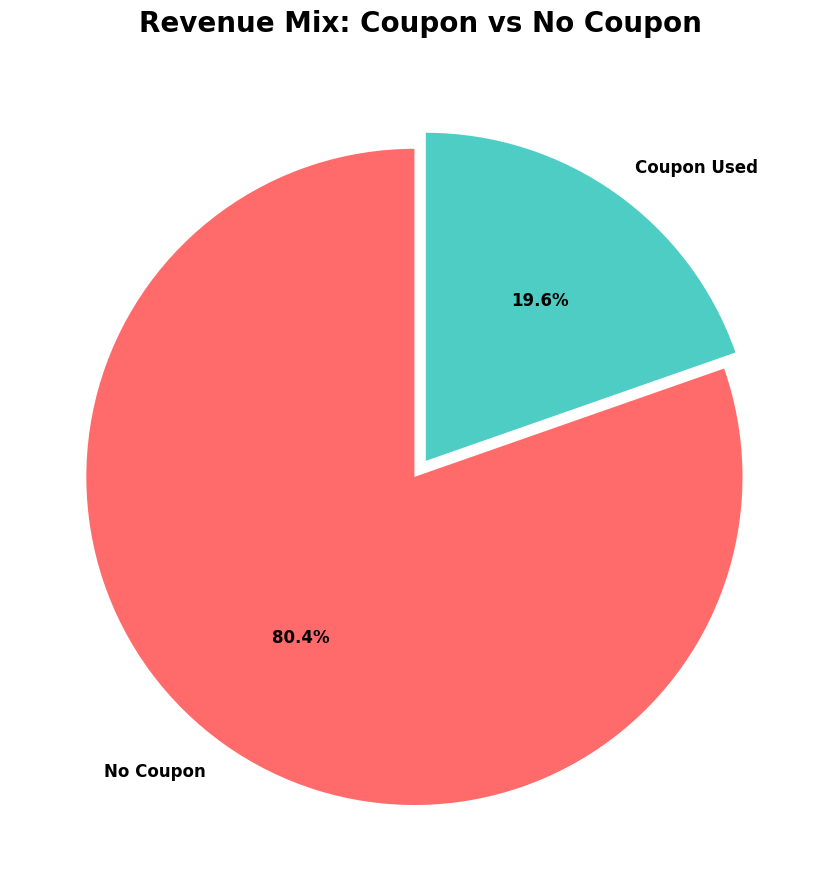

In [0]:
import matplotlib.pyplot as plt

pdf = coupon_vs_no_coupon.toPandas()

fig, ax = plt.subplots(figsize=(9, 9))

ax.pie(
    pdf["Gross_Revenue"],
    labels=pdf["Coupon_Type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#FF6B6B", "#4ECDC4"],
    explode=[0.03] * len(pdf),
    textprops={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

ax.set_title(
    "Revenue Mix: Coupon vs No Coupon",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()